<a href="https://colab.research.google.com/github/Salman9193/ml-finance-capstone/blob/main/finacial-markets-module/aurora_financial_markets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aurora Corp — Financial Markets Module: Investment Strategy
### Step 3 of the Aurora ML Finance System

**Objective:** Build an end-to-end ML investment pipeline for Aurora's equity portfolio:
1. **Return Prediction** — Forecast next-week stock returns using XGBoost & Random Forest
2. **Portfolio Optimisation** — Markowitz mean-variance framework using predicted returns
3. **Backtesting** — Rolling-window backtest over last 2 years
4. **Executive Dashboard** — ML insights for investment decisions

**Universe:** 6 NSE Blue-Chip Stocks — Asian Paints · Cipla · HDFC Bank · ITC · TCS · UltraTech Cement

---

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge

import xgboost as xgb
import shap
import scipy.optimize as sco
from scipy.stats import pearsonr

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid", palette="muted")

SECTOR_MAP = {
    "ASIAN PAINTS LTD."             : "Consumer Goods",
    "CIPLA LTD."                    : "Pharmaceuticals",
    "H D F C BANK LTD."             : "Banking & Finance",
    "I T C LTD."                    : "FMCG / Conglomerate",
    "TATA CONSULTANCY SERVICES LTD.": "Information Technology",
    "ULTRATECH CEMENT LTD."         : "Materials / Cement",
}
TICKER_MAP = {
    "ASIAN PAINTS LTD."             : "ASIANPAINT",
    "CIPLA LTD."                    : "CIPLA",
    "H D F C BANK LTD."             : "HDFCBANK",
    "I T C LTD."                    : "ITC",
    "TATA CONSULTANCY SERVICES LTD.": "TCS",
    "ULTRATECH CEMENT LTD."         : "ULTRACEMCO",
}
print("All libraries loaded")
print(f"XGBoost: {xgb.__version__}  |  SHAP: {shap.__version__}")

All libraries loaded
XGBoost: 3.2.0  |  SHAP: 0.51.0


---
## 1. Data Loading & Consolidation

In [2]:
FILE = "Market_Data_Revised.xlsx"
xl   = pd.ExcelFile(FILE)
print("Sheets:", xl.sheet_names)

# ── Load & consolidate all 6 company sheets ──────────────────────────────────
frames = []
for s in [s for s in xl.sheet_names if s.startswith("Comp")]:
    df = pd.read_excel(FILE, sheet_name=s, parse_dates=["date"])
    df["Ticker"] = df["company_name"].map(TICKER_MAP)
    df["Sector"] = df["company_name"].map(SECTOR_MAP)
    frames.append(df)

stock = pd.concat(frames, ignore_index=True)
stock.columns = [c.strip() for c in stock.columns]
stock.rename(columns={"date":"Date","opening":"Open","high":"High","low":"Low",
                       "closing":"Close","trade Volume":"Volume","Return":"Return"}, inplace=True)
stock.sort_values(["Ticker","Date"], inplace=True)
stock.reset_index(drop=True, inplace=True)

print(f"Consolidated shape: {stock.shape}")
print(f"Date range : {stock['Date'].min().date()}  →  {stock['Date'].max().date()}")
print(f"Tickers    : {stock['Ticker'].unique().tolist()}")
stock.head(8)

Sheets: ['Comp 1', 'Comp 2', 'Comp 3', 'Comp 4', 'Comp 5', 'Comp 6', 'Macroeconomic_QRT', 'Macroeconomic_Annual']
Consolidated shape: (31500, 11)
Date range : 2005-01-03  →  2026-02-27
Tickers    : ['ASIANPAINT', 'CIPLA', 'HDFCBANK', 'ITC', 'TCS', 'ULTRACEMCO']


,company_code,company_name,Date,Open,High,Low,Close,Volume,Return,Ticker,Sector
0,22859,ASIAN PAINTS LTD.,2005-01-03,320.10,325.00,318.60,319.10,17273,-0.003124,ASIANPAINT,Consumer Goods
1,22859,ASIAN PAINTS LTD.,2005-01-04,322.00,324.90,320.00,324.05,32240,0.006366,ASIANPAINT,Consumer Goods
2,22859,ASIAN PAINTS LTD.,2005-01-05,324.05,324.95,320.00,321.85,30500,-0.006789,ASIANPAINT,Consumer Goods
3,22859,ASIAN PAINTS LTD.,2005-01-06,327.00,327.00,302.55,309.45,38985,-0.053670,ASIANPAINT,Consumer Goods
4,22859,ASIAN PAINTS LTD.,2005-01-07,310.00,322.00,309.10,320.05,17621,0.032419,ASIANPAINT,Consumer Goods
5,22859,ASIAN PAINTS LTD.,2005-01-10,323.00,324.00,317.05,321.80,17363,-0.003715,ASIANPAINT,Consumer Goods
6,22859,ASIAN PAINTS LTD.,2005-01-11,318.10,321.95,318.05,320.30,24322,0.006916,ASIANPAINT,Consumer Goods
7,22859,ASIAN PAINTS LTD.,2005-01-12,320.00,320.00,312.00,316.90,14280,-0.009688,ASIANPAINT,Consumer Goods


In [3]:
# ── Load Macro data ─────────────────────────────────────────────────────────
macro_q = pd.read_excel(FILE, sheet_name="Macroeconomic_QRT", parse_dates=["Date"])
macro_q = macro_q[["Date","GDP Growth Rate","Inflation Rate (%)"]].dropna(subset=["Date"])
macro_q.columns = ["Date","GDP_Growth_QRT","Inflation_QRT"]
macro_q["Quarter"] = macro_q["Date"].dt.to_period("Q")

macro_a = pd.read_excel(FILE, sheet_name="Macroeconomic_Annual")
macro_a = macro_a[["Year","GDP growth (annual %)","Inflation, consumer prices (annual %)"]].dropna(subset=["Year"])
macro_a.columns = ["Year","GDP_Annual","Inflation_Annual"]
macro_a["Year"] = macro_a["Year"].astype(int)

print("Macro QRT shape:", macro_q.shape)
print("Macro Annual shape:", macro_a.shape)
print()
print(macro_q.head())

Macro QRT shape: (84, 4)
Macro Annual shape: (20, 3)

        Date  GDP_Growth_QRT  Inflation_QRT Quarter
0 2005-01-01        3.916985       0.254453  2005Q1
1 2005-04-01       -7.295595       0.571066  2005Q2
2 2005-07-01        0.349887       2.208202  2005Q3
3 2005-10-01       12.724114       1.913580  2005Q4
4 2006-01-01        5.237353      -0.242277  2006Q1


---
## 2. Exploratory Data Analysis (EDA)

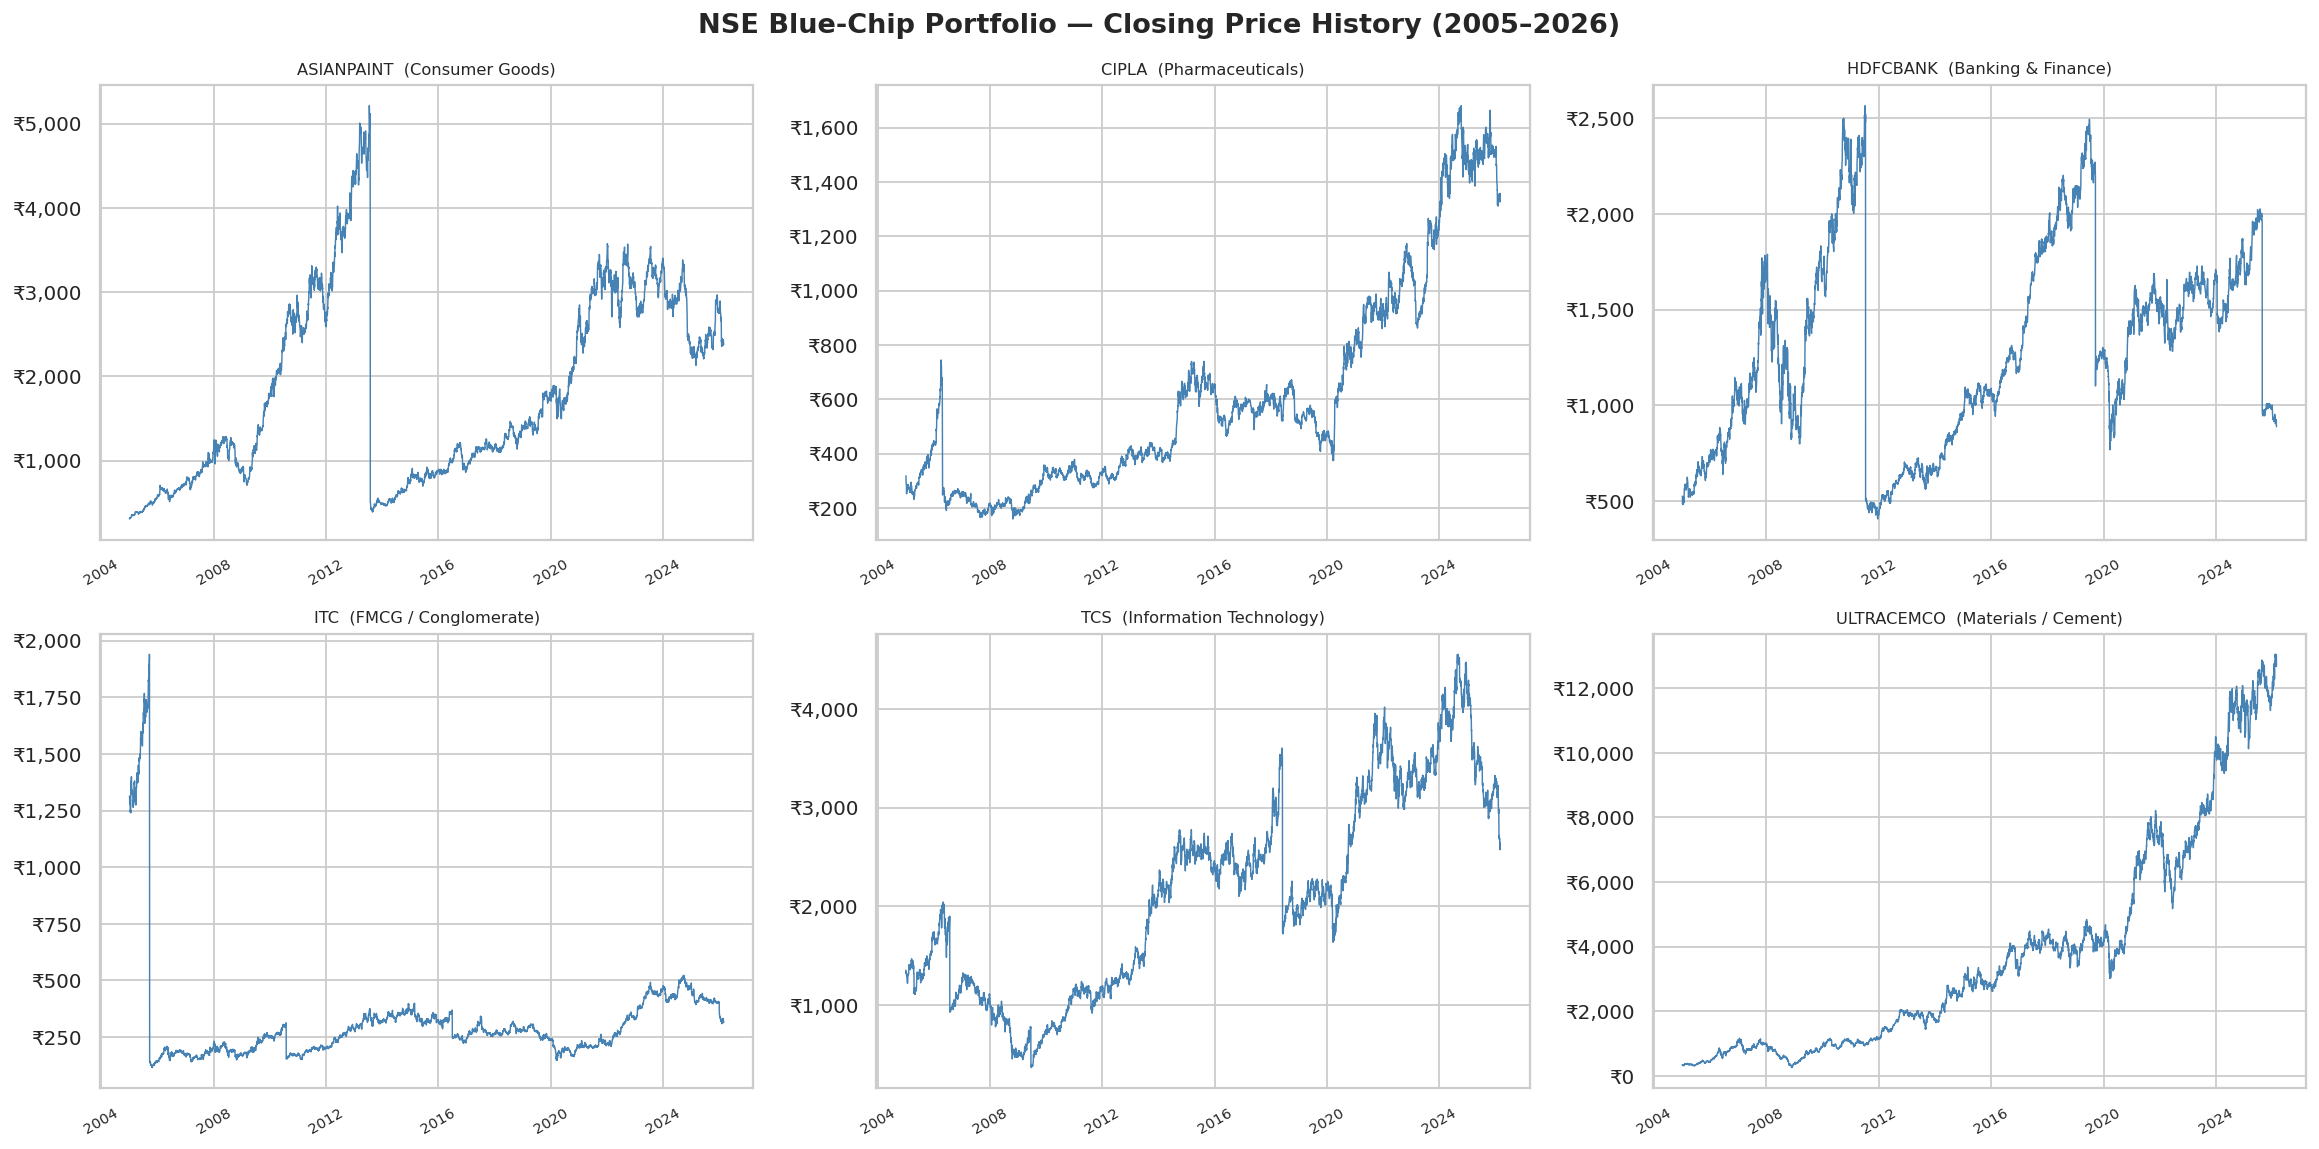

In [4]:
# ── Price history ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle("NSE Blue-Chip Portfolio — Closing Price History (2005–2026)",
             fontsize=15, fontweight="bold")

for ax, (ticker, grp) in zip(axes.flat, stock.groupby("Ticker")):
    ax.plot(grp["Date"], grp["Close"], lw=0.8, color="steelblue")
    ax.set_title(f"{ticker}  ({grp['Sector'].iloc[0]})", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

plt.tight_layout()
plt.savefig("01_price_history.png", bbox_inches="tight")
plt.show()

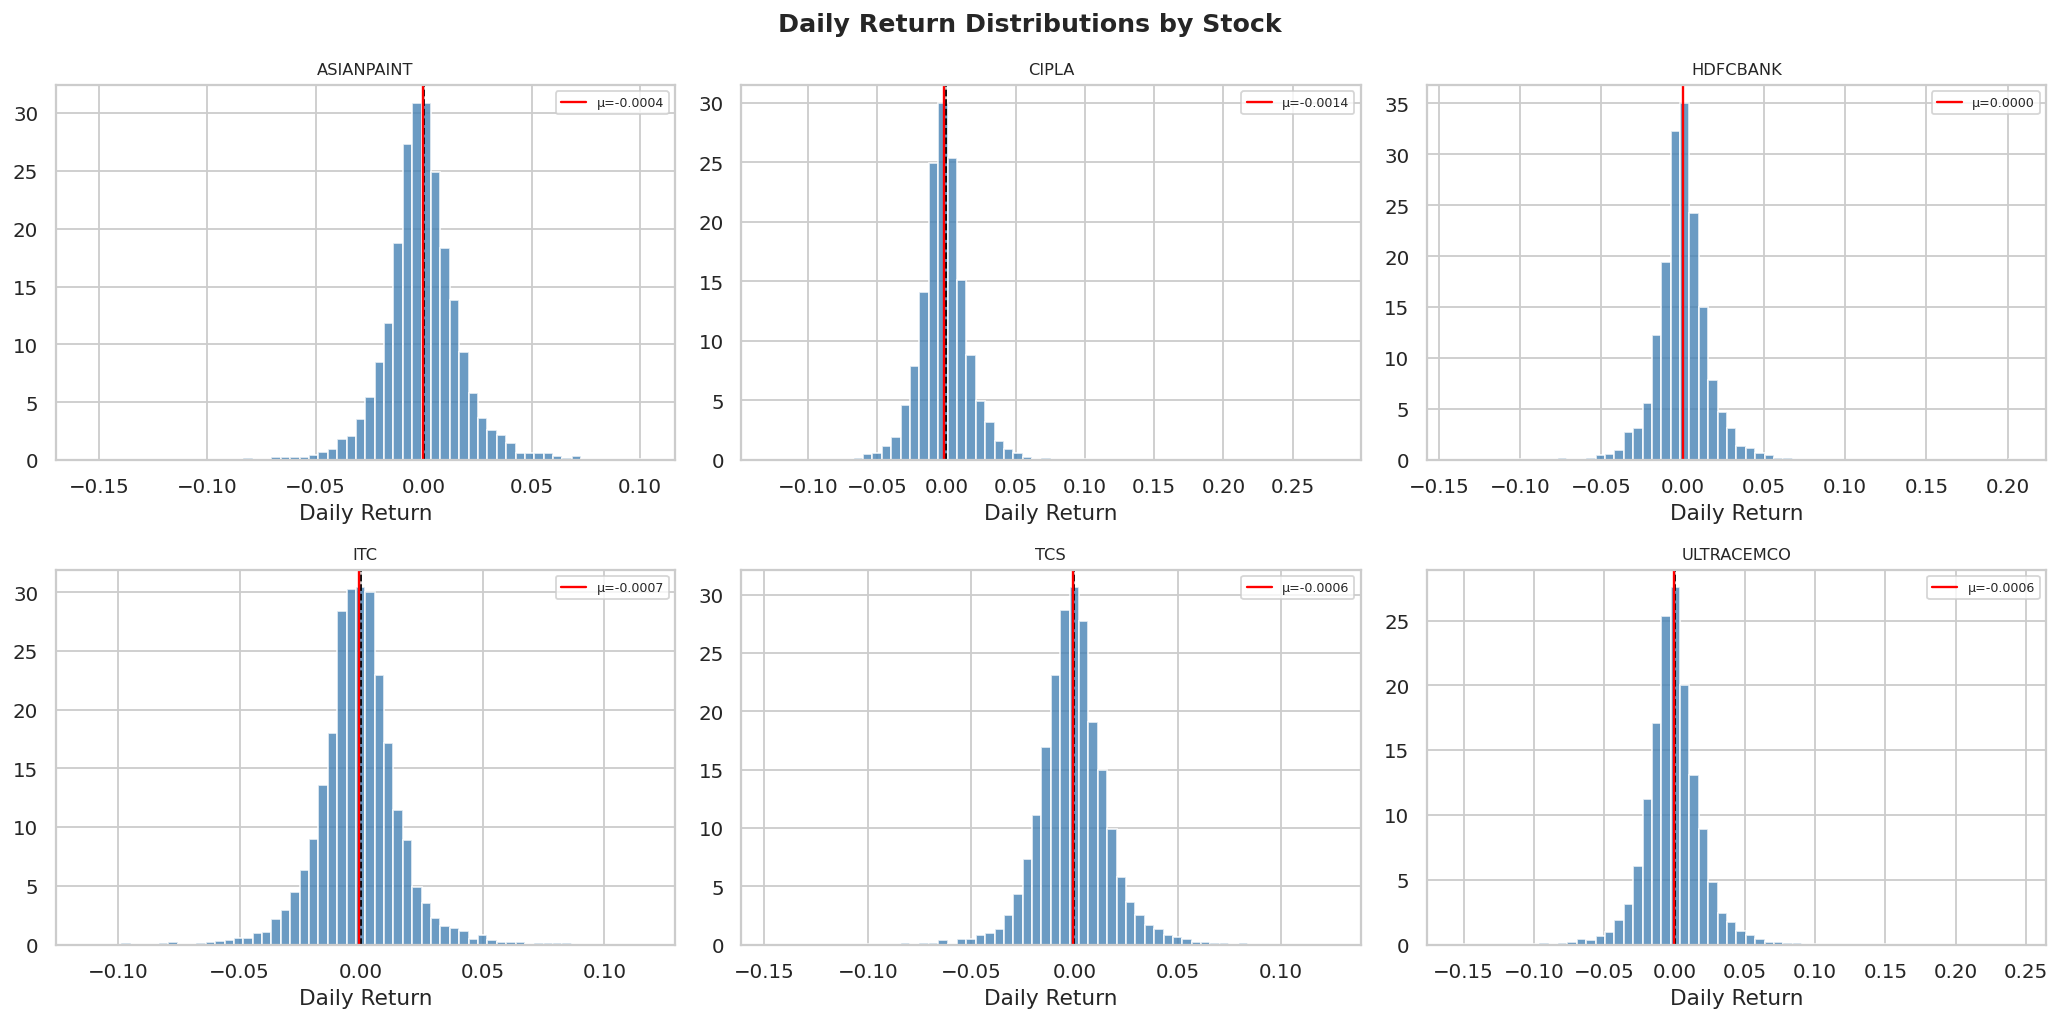


Return Statistics:
               Mean      Std     Skew      Kurt  Sharpe_Proxy
Ticker                                                       
ASIANPAINT -0.00040  0.01758 -0.13313   5.87282      -0.36095
CIPLA      -0.00143  0.01841  1.15026  19.41219      -1.23327
HDFCBANK    0.00005  0.01725  0.64944  14.53666       0.04209
ITC        -0.00074  0.01675  0.19855   4.28228      -0.69685
TCS        -0.00059  0.01760 -0.03492   5.87603      -0.53013
ULTRACEMCO -0.00064  0.02053  0.56679   9.05449      -0.49734


In [5]:
# ── Return distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Daily Return Distributions by Stock", fontsize=14, fontweight="bold")

stats = []
for ax, (ticker, grp) in zip(axes.flat, stock.groupby("Ticker")):
    ax.hist(grp["Return"], bins=60, color="steelblue", edgecolor="white", alpha=0.8, density=True)
    ax.axvline(0, color="black", linestyle="--", lw=1)
    ax.axvline(grp["Return"].mean(), color="red", linestyle="-", lw=1.3,
               label=f"μ={grp['Return'].mean():.4f}")
    ax.set_title(ticker, fontsize=9)
    ax.set_xlabel("Daily Return")
    ax.legend(fontsize=7)
    stats.append({"Ticker": ticker, "Mean": grp["Return"].mean(),
                  "Std": grp["Return"].std(), "Skew": grp["Return"].skew(),
                  "Kurt": grp["Return"].kurtosis(), "Sharpe_Proxy": grp["Return"].mean()/grp["Return"].std()*np.sqrt(252)})

plt.tight_layout()
plt.savefig("02_return_distributions.png", bbox_inches="tight")
plt.show()

stats_df = pd.DataFrame(stats).set_index("Ticker").round(5)
print("\nReturn Statistics:")
print(stats_df.to_string())

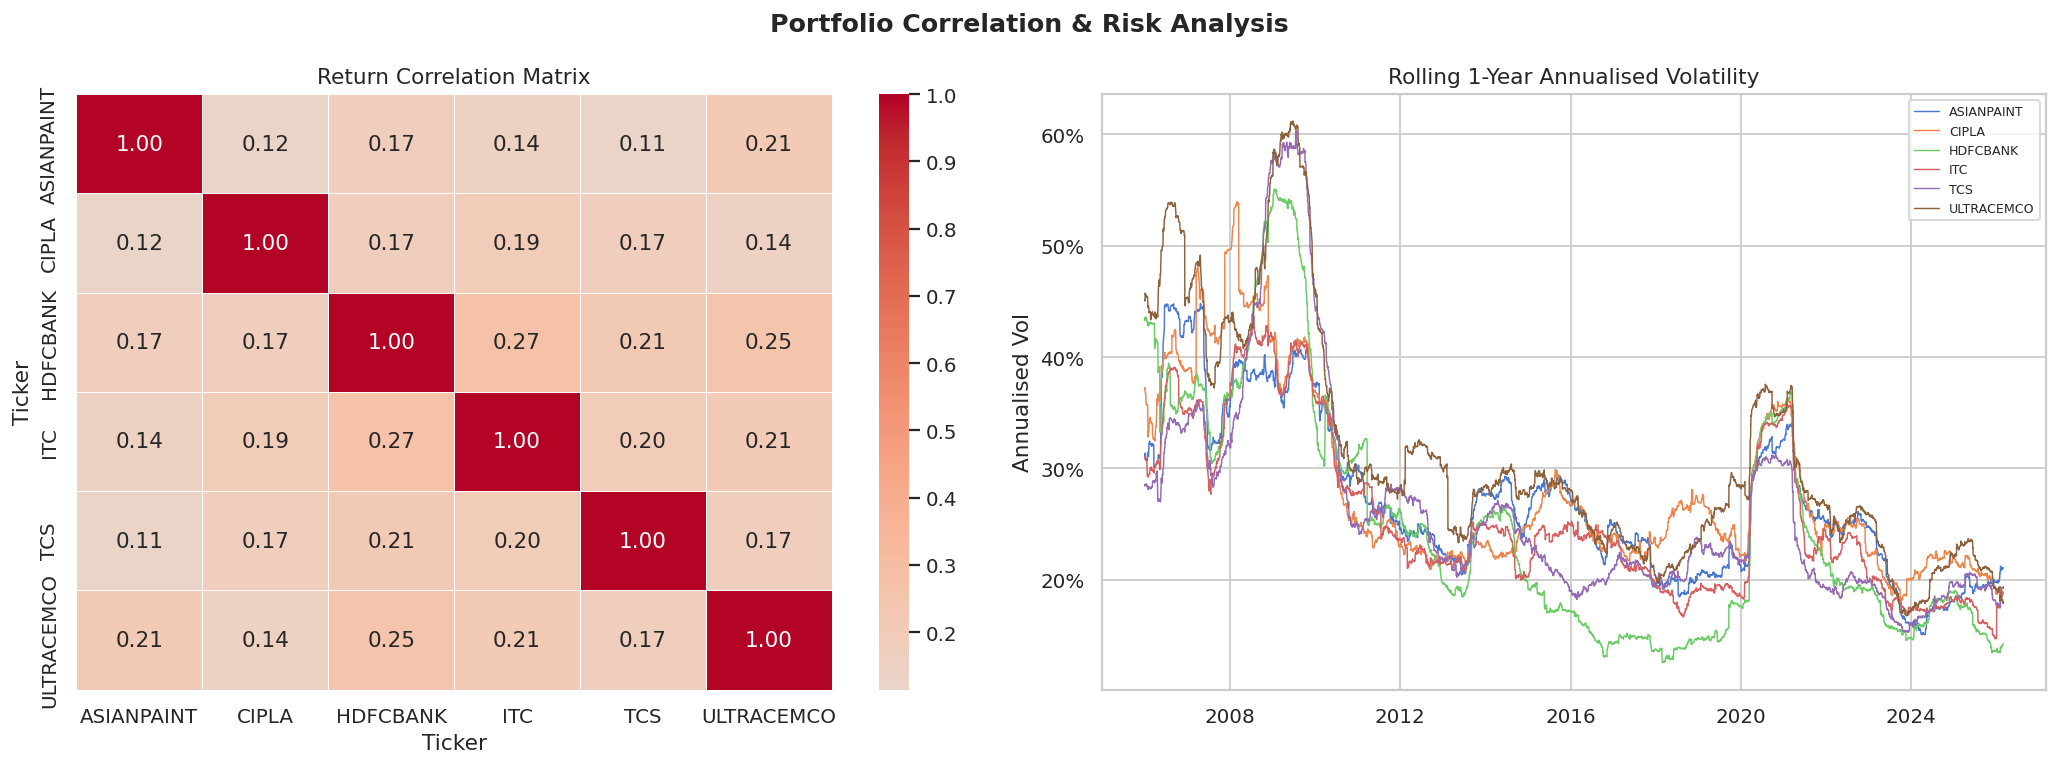

In [6]:
# ── Correlation matrix (annual returns) ─────────────────────────────────────
pivot_ret = stock.pivot(index="Date", columns="Ticker", values="Return").dropna()
corr = pivot_ret.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Portfolio Correlation & Risk Analysis", fontsize=14, fontweight="bold")

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=axes[0])
axes[0].set_title("Return Correlation Matrix")

# Rolling 252-day volatility
for ticker, grp in stock.groupby("Ticker"):
    vol = grp.set_index("Date")["Return"].rolling(252).std() * np.sqrt(252)
    axes[1].plot(vol, lw=0.8, label=ticker)
axes[1].set_title("Rolling 1-Year Annualised Volatility")
axes[1].set_ylabel("Annualised Vol")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1].legend(fontsize=7)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("03_correlation_volatility.png", bbox_inches="tight")
plt.show()

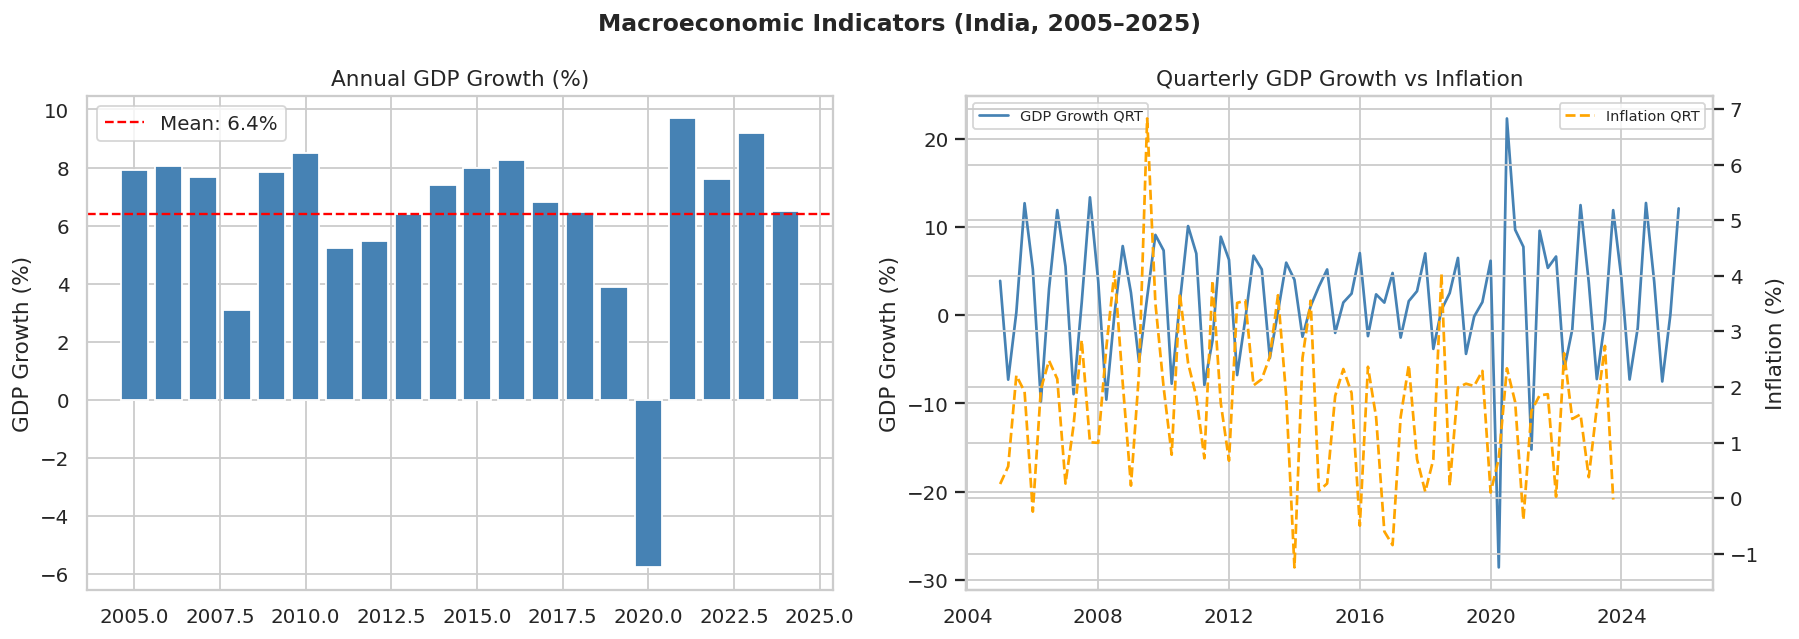

In [7]:
# ── Macro indicators ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Macroeconomic Indicators (India, 2005–2025)", fontsize=13, fontweight="bold")

axes[0].bar(macro_a["Year"], macro_a["GDP_Annual"], color="steelblue", edgecolor="white")
axes[0].axhline(macro_a["GDP_Annual"].mean(), color="red", linestyle="--", lw=1.3,
                label=f"Mean: {macro_a['GDP_Annual'].mean():.1f}%")
axes[0].set_title("Annual GDP Growth (%)")
axes[0].set_ylabel("GDP Growth (%)")
axes[0].legend()

axes[1].plot(macro_q["Date"], macro_q["GDP_Growth_QRT"], lw=1.5,
             color="steelblue", label="GDP Growth QRT")
ax2 = axes[1].twinx()
ax2.plot(macro_q["Date"], macro_q["Inflation_QRT"], lw=1.5,
         color="orange", linestyle="--", label="Inflation QRT")
axes[1].set_title("Quarterly GDP Growth vs Inflation")
axes[1].set_ylabel("GDP Growth (%)")
ax2.set_ylabel("Inflation (%)")
axes[1].legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("04_macro_indicators.png", bbox_inches="tight")
plt.show()

---
## 3. Feature Engineering — Technical & Macro Indicators

Technical indicators encode price momentum, trend, and volatility signals.
They are the "language" of quantitative finance — the features the model needs to learn market patterns.

In [8]:
def add_features(df):
    df = df.copy().sort_values("Date").reset_index(drop=True)
    c = df["Close"]
    v = df["Return"]

    # ── Momentum / Trend ─────────────────────────────────────────────────────
    df["MA5"]   = c.rolling(5).mean()
    df["MA20"]  = c.rolling(20).mean()
    df["MA50"]  = c.rolling(50).mean()
    df["EMA12"] = c.ewm(span=12, adjust=False).mean()
    df["EMA26"] = c.ewm(span=26, adjust=False).mean()
    df["MACD"]  = df["EMA12"] - df["EMA26"]

    # Price relative to moving averages (normalised)
    df["Price_vs_MA20"] = (c / df["MA20"]) - 1
    df["Price_vs_MA50"] = (c / df["MA50"]) - 1

    # ── Volatility ───────────────────────────────────────────────────────────
    df["Vol5"]  = v.rolling(5).std()
    df["Vol20"] = v.rolling(20).std()
    df["ATR"]   = (df["High"] - df["Low"]).rolling(14).mean()   # Average True Range

    # Bollinger Bands — price position within the band
    bb_mid = c.rolling(20).mean()
    bb_std = c.rolling(20).std()
    df["BB_Upper"] = bb_mid + 2*bb_std
    df["BB_Lower"] = bb_mid - 2*bb_std
    df["BB_Position"] = (c - bb_mid) / (2*bb_std + 1e-10)   # -1 to +1

    # ── RSI (14-day) ─────────────────────────────────────────────────────────
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-10)
    df["RSI"] = 100 - (100 / (1 + rs))

    # ── Volume features ──────────────────────────────────────────────────────
    df["Vol_MA20"]     = df["Volume"].rolling(20).mean()
    df["Vol_Ratio"]    = df["Volume"] / (df["Vol_MA20"] + 1)   # relative volume surge
    df["OBV"]          = (np.sign(v) * df["Volume"]).cumsum()   # On-Balance Volume

    # ── Lagged returns ───────────────────────────────────────────────────────
    for lag in [1, 2, 3, 5, 10]:
        df[f"Ret_Lag{lag}"] = v.shift(lag)

    # ── Calendar features ────────────────────────────────────────────────────
    df["DayOfWeek"]  = df["Date"].dt.dayofweek
    df["Month"]      = df["Date"].dt.month
    df["Quarter"]    = df["Date"].dt.quarter

    # ── Target: next-week return (5 trading days forward) ────────────────────
    df["Target_Week"] = v.shift(-5).rolling(5).sum()   # cumulative 5-day return
    df["Target_Day"]  = v.shift(-1)                    # next-day return

    return df

# Apply to all tickers
stock_fe = []
for ticker, grp in stock.groupby("Ticker"):
    stock_fe.append(add_features(grp))
stock_fe = pd.concat(stock_fe, ignore_index=True)

print(f"Features added. New shape: {stock_fe.shape}")
print(f"New columns: {[c for c in stock_fe.columns if c not in stock.columns]}")

Features added. New shape: (31500, 39)
New columns: ['MA5', 'MA20', 'MA50', 'EMA12', 'EMA26', 'MACD', 'Price_vs_MA20', 'Price_vs_MA50', 'Vol5', 'Vol20', 'ATR', 'BB_Upper', 'BB_Lower', 'BB_Position', 'RSI', 'Vol_MA20', 'Vol_Ratio', 'OBV', 'Ret_Lag1', 'Ret_Lag2', 'Ret_Lag3', 'Ret_Lag5', 'Ret_Lag10', 'DayOfWeek', 'Month', 'Quarter', 'Target_Week', 'Target_Day']


In [9]:
# ── Merge macro data ─────────────────────────────────────────────────────────
stock_fe["Quarter_Period"] = stock_fe["Date"].dt.to_period("Q")
macro_q["Quarter_Period"]  = macro_q["Date"].dt.to_period("Q")
stock_fe = stock_fe.merge(macro_q[["Quarter_Period","GDP_Growth_QRT","Inflation_QRT"]],
                           on="Quarter_Period", how="left")

stock_fe["Year"] = stock_fe["Date"].dt.year
stock_fe = stock_fe.merge(macro_a[["Year","GDP_Annual","Inflation_Annual"]],
                           on="Year", how="left")

print("Macro merged. Final shape:", stock_fe.shape)
print("NaN in macro cols:", stock_fe[["GDP_Growth_QRT","Inflation_QRT","GDP_Annual"]].isnull().sum().to_dict())

Macro merged. Final shape: (31500, 45)
NaN in macro cols: {'GDP_Growth_QRT': 246, 'Inflation_QRT': 3234, 'GDP_Annual': 1740}


---
## 4. Return Prediction — ML Models

We predict **next-week cumulative return** using XGBoost, Random Forest, and Ridge regression.
This is a supervised regression problem: features are technical + macro signals, target is 5-day forward return.

**Time-Series discipline:** We use `TimeSeriesSplit` — never shuffle past and future data in the same fold.

In [10]:
FEATURES = ["MA5","MA20","MA50","MACD","Price_vs_MA20","Price_vs_MA50",
            "Vol5","Vol20","ATR","BB_Position","RSI","Vol_Ratio",
            "Ret_Lag1","Ret_Lag2","Ret_Lag3","Ret_Lag5","Ret_Lag10",
            "DayOfWeek","Month","Quarter",
            "GDP_Growth_QRT","Inflation_QRT","GDP_Annual","Inflation_Annual"]

TARGET = "Target_Week"

# Use data up to end-2023 for training; 2024+ for backtesting
TRAIN_END = "2022-12-31"
BACKTEST_START = "2023-01-01"

# Drop rows with NaN in features or target
ml_data = stock_fe.dropna(subset=FEATURES + [TARGET]).copy()
train_data = ml_data[ml_data["Date"] <= TRAIN_END]
test_data  = ml_data[ml_data["Date"] >= BACKTEST_START]

print(f"Total ML rows   : {len(ml_data)}")
print(f"Training rows   : {len(train_data)}  (up to {TRAIN_END})")
print(f"Backtest rows   : {len(test_data)}  (from {BACKTEST_START})")
print(f"Features        : {len(FEATURES)}")

Total ML rows   : 27972
Training rows   : 26496  (up to 2022-12-31)
Backtest rows   : 1476  (from 2023-01-01)
Features        : 24


In [11]:
X_train = train_data[FEATURES]
y_train = train_data[TARGET]
X_test  = test_data[FEATURES]
y_test  = test_data[TARGET]

# Models
xgb_ret = xgb.XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03,
                             subsample=0.8, colsample_bytree=0.7,
                             random_state=42, verbosity=0)
rf_ret  = RandomForestRegressor(n_estimators=300, max_depth=6,
                                  min_samples_leaf=5, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
ridge   = Ridge(alpha=1.0)

results = {}
tscv = TimeSeriesSplit(n_splits=5)

for name, model, X_tr, X_te in [("XGBoost", xgb_ret, X_train, X_test),
                                   ("Random Forest", rf_ret, X_train, X_test),
                                   ("Ridge", ridge, X_train_s, X_test_s)]:
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    ic    = np.corrcoef(y_test, preds)[0,1]   # Information Coefficient
    cv_r2 = cross_val_score(model, X_tr, y_train, cv=tscv, scoring="r2").mean()
    results[name] = {"model": model, "preds": preds,
                     "MAE": mae, "R2": r2, "IC": ic, "CV_R2": cv_r2}
    print(f"{name:15s} | MAE: {mae:.5f} | R²: {r2:.4f} | IC: {ic:.4f} | TS 5-CV R²: {cv_r2:.4f}")

XGBoost         | MAE: 0.01861 | R²: -0.0493 | IC: 0.0096 | TS 5-CV R²: -0.2851
Random Forest   | MAE: 0.01830 | R²: -0.0156 | IC: -0.0401 | TS 5-CV R²: -0.1186
Ridge           | MAE: 0.01855 | R²: -0.0432 | IC: -0.0152 | TS 5-CV R²: -0.0091


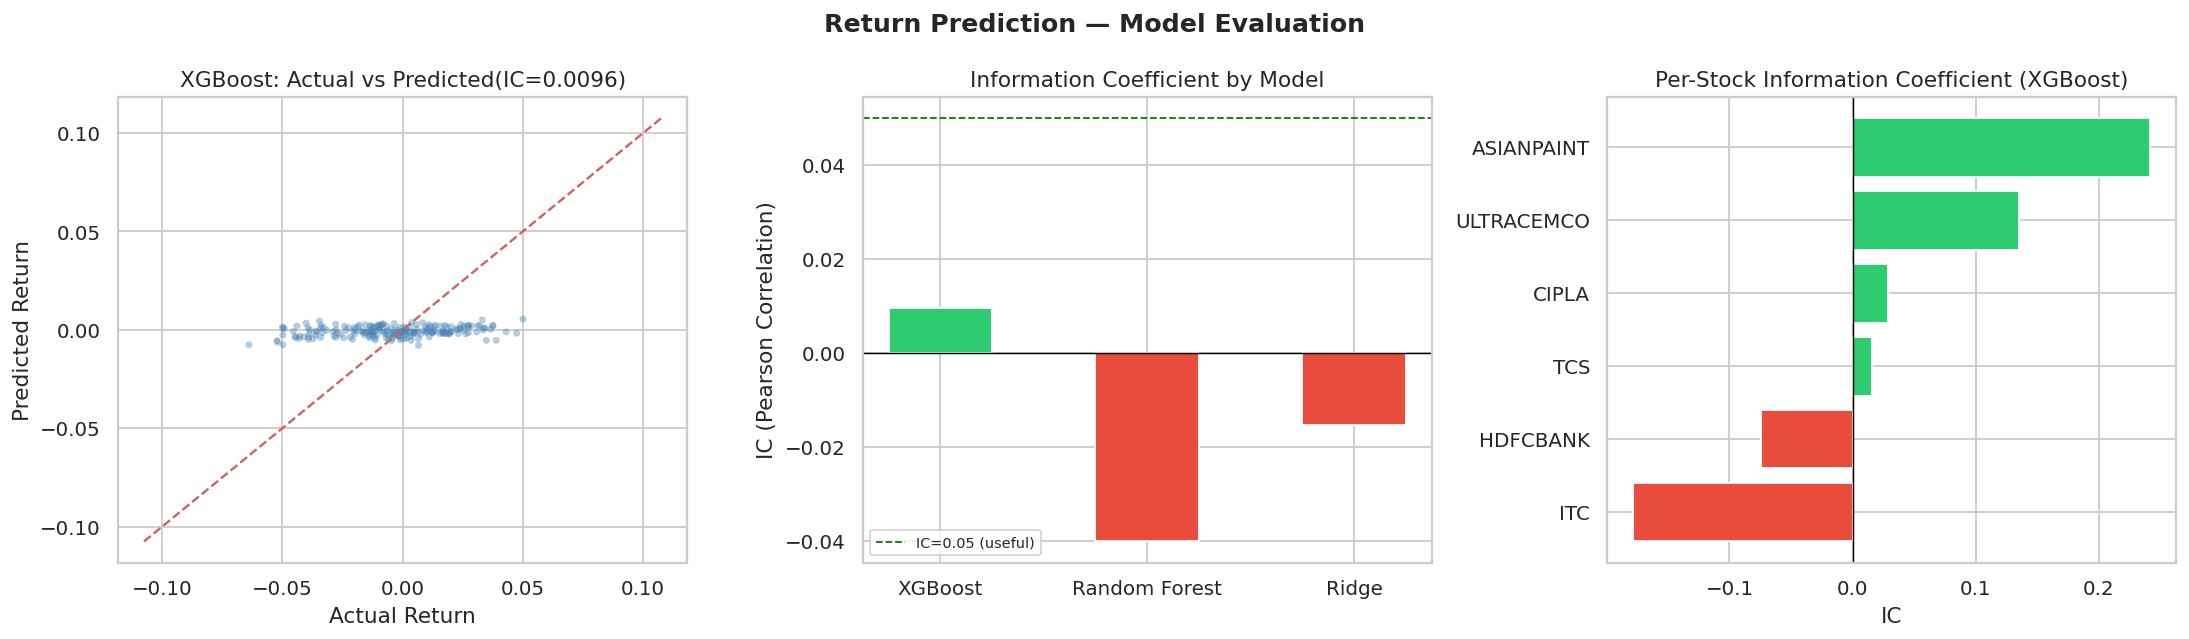

In [12]:
# ── Prediction plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Return Prediction — Model Evaluation", fontsize=14, fontweight="bold")

# Actual vs Predicted (XGBoost)
axes[0].scatter(y_test[:200], results["XGBoost"]["preds"][:200],
                alpha=0.4, s=15, color="steelblue", edgecolors="none")
lim = max(abs(y_test).max(), abs(results["XGBoost"]["preds"]).max()) * 1.1
axes[0].plot([-lim, lim], [-lim, lim], "r--", lw=1.3)
axes[0].set_xlabel("Actual Return")
axes[0].set_ylabel("Predicted Return")
axes[0].set_title(f"XGBoost: Actual vs Predicted(IC={results['XGBoost']['IC']:.4f})")

# IC comparison bar
ics = {k: v["IC"] for k, v in results.items()}
bar_colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in ics.values()]
axes[1].bar(ics.keys(), ics.values(), color=bar_colors, edgecolor="white", width=0.5)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhline(0.05, color="green", linestyle="--", lw=1, label="IC=0.05 (useful)")
axes[1].set_title("Information Coefficient by Model")
axes[1].set_ylabel("IC (Pearson Correlation)")
axes[1].legend(fontsize=8)

# Per-stock IC
ic_by_ticker = []
for ticker, grp in test_data.groupby("Ticker"):
    grp_clean = grp[FEATURES + [TARGET]].dropna()
    if len(grp_clean) > 10:
        preds = xgb_ret.predict(grp_clean[FEATURES])
        ic = np.corrcoef(grp_clean[TARGET], preds)[0,1]
        ic_by_ticker.append({"Ticker": ticker, "IC": ic})
ic_df = pd.DataFrame(ic_by_ticker).sort_values("IC", ascending=True)
colors_ic = ["#2ecc71" if v > 0 else "#e74c3c" for v in ic_df["IC"]]
axes[2].barh(ic_df["Ticker"], ic_df["IC"], color=colors_ic, edgecolor="white")
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set_title("Per-Stock Information Coefficient (XGBoost)")
axes[2].set_xlabel("IC")

plt.tight_layout()
plt.savefig("05_return_prediction.png", bbox_inches="tight")
plt.show()

---
## 5. SHAP Explainability — What Drives Return Predictions?

In [13]:
explainer = shap.TreeExplainer(xgb_ret)
# Use a 500-row sample for speed
sample_idx = np.random.choice(len(X_train), 500, replace=False)
shap_vals  = explainer.shap_values(X_train.iloc[sample_idx])

shap_imp = pd.Series(np.abs(shap_vals).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print("Top 10 SHAP drivers — Return Prediction:")
print(shap_imp.head(10).round(5).to_string())

Top 10 SHAP drivers — Return Prediction:
Inflation_Annual    0.00223
MA50                0.00220
Month               0.00183
ATR                 0.00167
Price_vs_MA50       0.00119
MACD                0.00104
Vol20               0.00103
GDP_Growth_QRT      0.00093
MA20                0.00088
Vol5                0.00081


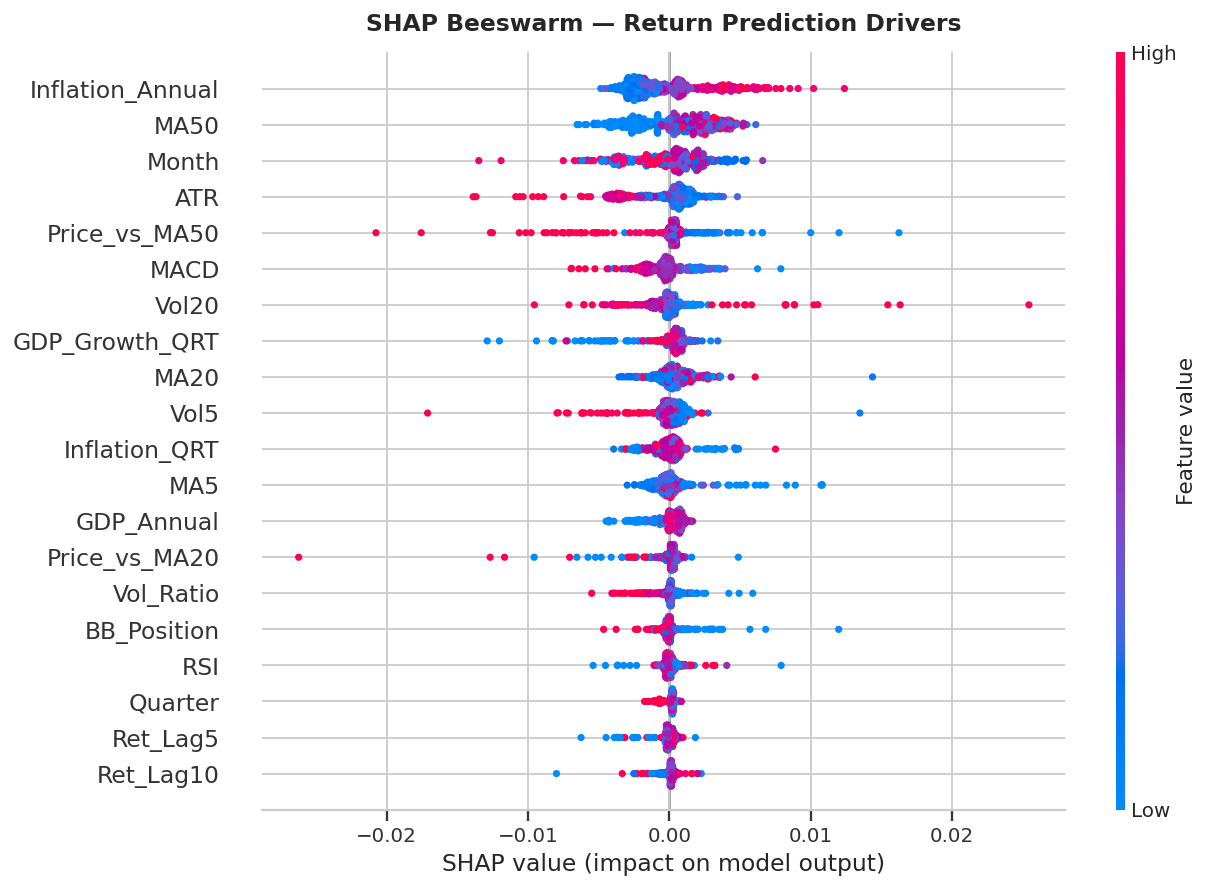

In [14]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_train.iloc[sample_idx], feature_names=FEATURES,
                  show=False, plot_size=(10, 7))
plt.title("SHAP Beeswarm — Return Prediction Drivers", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("06_shap_returns.png", bbox_inches="tight", dpi=130)
plt.show()

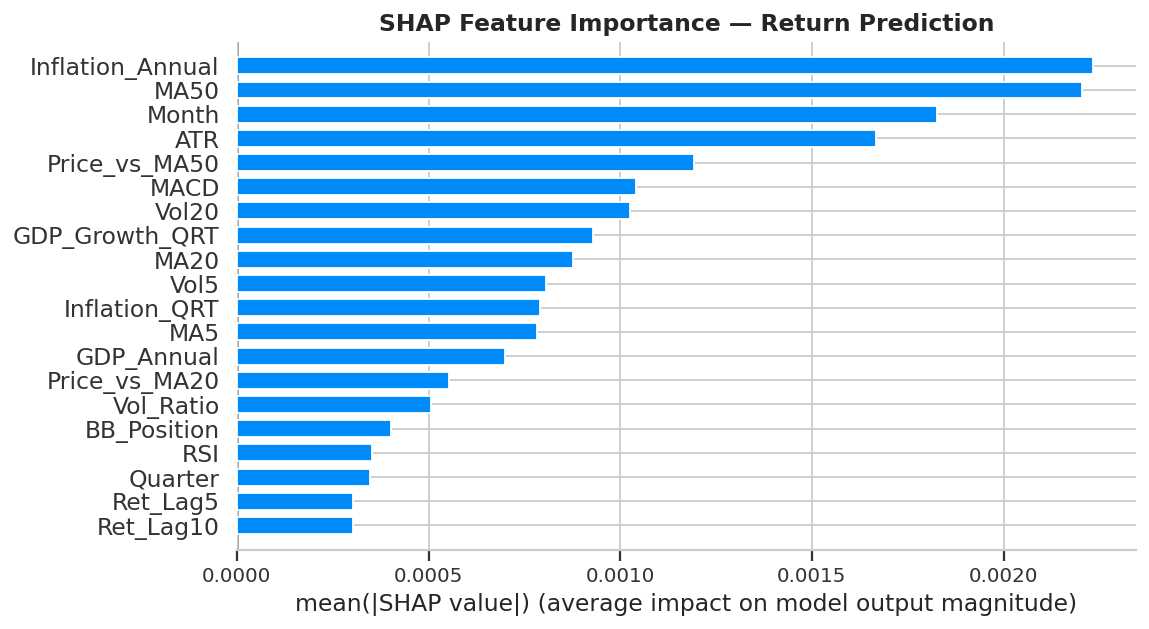

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(shap_vals, X_train.iloc[sample_idx], feature_names=FEATURES,
                  plot_type="bar", show=False, plot_size=(9, 5))
ax = plt.gca()
ax.set_title("SHAP Feature Importance — Return Prediction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("07_shap_bar.png", bbox_inches="tight", dpi=130)
plt.show()

---
## 6. Predicted Return Ranking

We score every stock on its average predicted weekly return over the backtest period.
The ranking tells Aurora which stocks the model expects to outperform.

In [16]:
test_data = test_data.copy()
test_data["Pred_Week_Return"] = xgb_ret.predict(test_data[FEATURES])

# Average predicted return and actual return per ticker
ranking = test_data.groupby("Ticker").agg(
    Avg_Pred_Return   = ("Pred_Week_Return", "mean"),
    Avg_Actual_Return = (TARGET, "mean"),
    Pred_Std          = ("Pred_Week_Return", "std"),
    Sharpe_Pred       = ("Pred_Week_Return", lambda x: x.mean()/x.std() if x.std()>0 else 0)
).reset_index().sort_values("Avg_Pred_Return", ascending=False)

ranking["Rank"] = range(1, len(ranking)+1)
ranking["Sector"] = ranking["Ticker"].map({v:SECTOR_MAP[k] for k,v in TICKER_MAP.items()})
ranking["Signal"] = ranking["Avg_Pred_Return"].apply(
    lambda x: "BUY" if x > 0.005 else ("HOLD" if x > 0 else "REDUCE"))

print("=" * 75)
print("STOCK RETURN RANKING — Backtest Period (2024–2026)")
print("=" * 75)
print(ranking[["Rank","Ticker","Sector","Avg_Pred_Return","Avg_Actual_Return",
               "Sharpe_Pred","Signal"]].to_string(index=False))

STOCK RETURN RANKING — Backtest Period (2024–2026)
 Rank     Ticker                 Sector  Avg_Pred_Return  Avg_Actual_Return  Sharpe_Pred Signal
    1   HDFCBANK      Banking & Finance         0.000560          -0.003235     0.158573   HOLD
    2 ASIANPAINT         Consumer Goods        -0.000786          -0.002890    -0.335919 REDUCE
    3        TCS Information Technology        -0.000789           0.000921    -0.214866 REDUCE
    4      CIPLA        Pharmaceuticals        -0.002138          -0.005277    -0.395842 REDUCE
    5        ITC    FMCG / Conglomerate        -0.002228           0.000234    -0.450624 REDUCE
    6 ULTRACEMCO     Materials / Cement        -0.008633          -0.001310    -1.382007 REDUCE


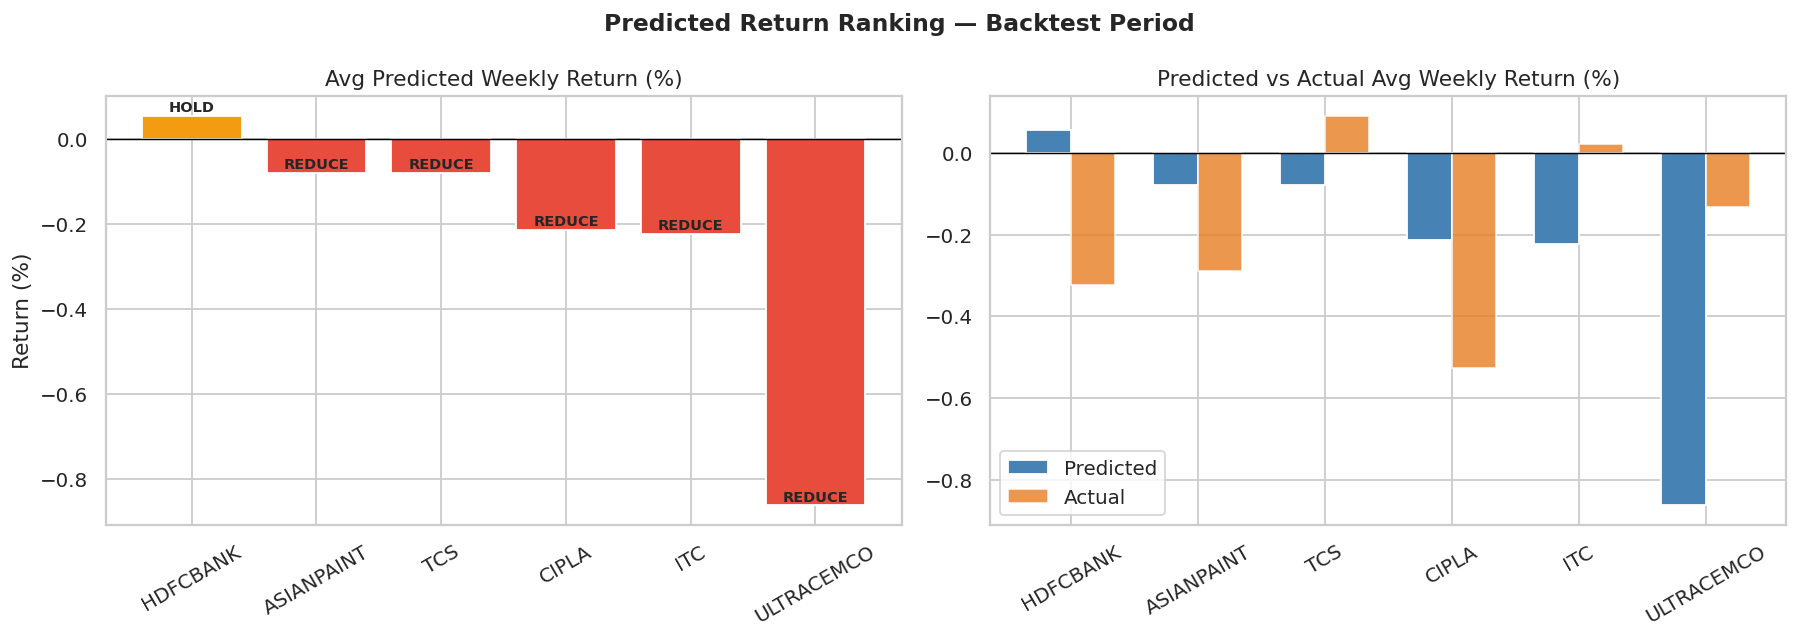

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Predicted Return Ranking — Backtest Period", fontsize=13, fontweight="bold")

colors = ["#2ecc71" if s=="BUY" else "#f39c12" if s=="HOLD" else "#e74c3c"
          for s in ranking["Signal"]]
axes[0].bar(ranking["Ticker"], ranking["Avg_Pred_Return"]*100,
            color=colors, edgecolor="white")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Avg Predicted Weekly Return (%)")
axes[0].set_ylabel("Return (%)")
axes[0].tick_params(axis="x", rotation=30)
for i, (_, row) in enumerate(ranking.iterrows()):
    axes[0].text(i, row["Avg_Pred_Return"]*100 + 0.01,
                 row["Signal"], ha="center", fontsize=8, fontweight="bold")

# Pred vs Actual
x = np.arange(len(ranking))
w = 0.35
axes[1].bar(x-w/2, ranking["Avg_Pred_Return"]*100, w,
            label="Predicted", color="steelblue", edgecolor="white")
axes[1].bar(x+w/2, ranking["Avg_Actual_Return"]*100, w,
            label="Actual", color="#e67e22", edgecolor="white", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ranking["Ticker"], rotation=30)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Predicted vs Actual Avg Weekly Return (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("08_return_ranking.png", bbox_inches="tight")
plt.show()

---
## 7. Portfolio Optimisation — Markowitz Mean-Variance

We build three portfolios using the Markowitz framework:
1. **Max Sharpe Ratio** — highest risk-adjusted return
2. **Min Variance** — lowest portfolio risk
3. **ML-Tilted** — uses ML predicted returns as the expected return vector (alpha tilted)

The covariance matrix is estimated from the training period (2005–2023).

In [18]:
# ── Compute expected returns and covariance matrix ──────────────────────────
TICKERS = sorted(stock["Ticker"].unique().tolist())

# Weekly returns matrix (5-day rolling sum)
weekly = pivot_ret[TICKERS].copy()

# Training period only for covariance estimation
train_rets = weekly[weekly.index <= TRAIN_END].dropna()

# Annualised expected returns (from historical mean)
mu_hist = train_rets.mean() * 252     # annualised
cov     = train_rets.cov()  * 252     # annualised covariance

# ML-predicted expected returns (from ranking)
ml_pred = ranking.set_index("Ticker")["Avg_Pred_Return"] * 52   # annualised from weekly
mu_ml   = pd.Series({t: ml_pred.get(t, mu_hist[t]) for t in TICKERS})

print("Annualised expected returns (historical):")
print(mu_hist.round(4).to_string())
print()
print("Annualised expected returns (ML predicted):")
print(mu_ml.round(4).to_string())

Annualised expected returns (historical):
Ticker
ASIANPAINT   -0.0861
CIPLA        -0.3890
HDFCBANK      0.0123
ITC          -0.1717
TCS          -0.1561
ULTRACEMCO   -0.1769

Annualised expected returns (ML predicted):
ASIANPAINT   -0.0409
CIPLA        -0.1112
HDFCBANK      0.0291
ITC          -0.1158
TCS          -0.0410
ULTRACEMCO   -0.4489


In [19]:
# ── Efficient Frontier ─────────────────────────────────────────────────────
n = len(TICKERS)
cov_np  = cov.values
rf_rate = 0.065   # India risk-free rate ~6.5% (91-day T-bill)

def portfolio_performance(weights, mu, cov):
    ret = weights @ mu
    vol = np.sqrt(weights @ cov @ weights)
    sr  = (ret - rf_rate) / vol
    return ret, vol, sr

def neg_sharpe(w, mu, cov):
    _, _, sr = portfolio_performance(w, mu, cov)
    return -sr

def portfolio_vol(w, cov):
    return np.sqrt(w @ cov @ w)

constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds = [(0, 0.40)] * n   # no shorting, max 40% per stock

# Max Sharpe — historical
w0 = np.ones(n)/n
opt_sharpe = sco.minimize(neg_sharpe, w0, args=(mu_hist.values, cov_np),
                           method="SLSQP", bounds=bounds, constraints=constraints)
w_sharpe = opt_sharpe.x

# Min Variance
opt_minvar = sco.minimize(portfolio_vol, w0, args=(cov_np,),
                           method="SLSQP", bounds=bounds, constraints=constraints)
w_minvar = opt_minvar.x

# ML-tilted Max Sharpe
opt_ml = sco.minimize(neg_sharpe, w0, args=(mu_ml.values, cov_np),
                       method="SLSQP", bounds=bounds, constraints=constraints)
w_ml = opt_ml.x

# Efficient frontier points
ef_vols, ef_rets = [], []
for target_ret in np.linspace(mu_hist.min(), mu_hist.max(), 100):
    cons = constraints + [{"type": "eq", "fun": lambda w: w @ mu_hist.values - target_ret}]
    res = sco.minimize(portfolio_vol, w0, args=(cov_np,),
                       method="SLSQP", bounds=bounds, constraints=cons)
    if res.success:
        ef_vols.append(res.fun)
        ef_rets.append(target_ret)

print("Optimal Portfolios:")
for name, w, mu_use in [("Max Sharpe (Hist)", w_sharpe, mu_hist.values),
                         ("Min Variance",      w_minvar, mu_hist.values),
                         ("ML-Tilted Sharpe",  w_ml,     mu_ml.values)]:
    r, v, s = portfolio_performance(w, mu_use, cov_np)
    print(f"{name:22s} | Ret: {r:.2%} | Vol: {v:.2%} | Sharpe: {s:.3f}")

Optimal Portfolios:
Max Sharpe (Hist)      | Ret: -6.49% | Vol: 20.91% | Sharpe: -0.621
Min Variance           | Ret: -16.14% | Vol: 16.75% | Sharpe: -1.352
ML-Tilted Sharpe       | Ret: -1.29% | Vol: 20.07% | Sharpe: -0.388


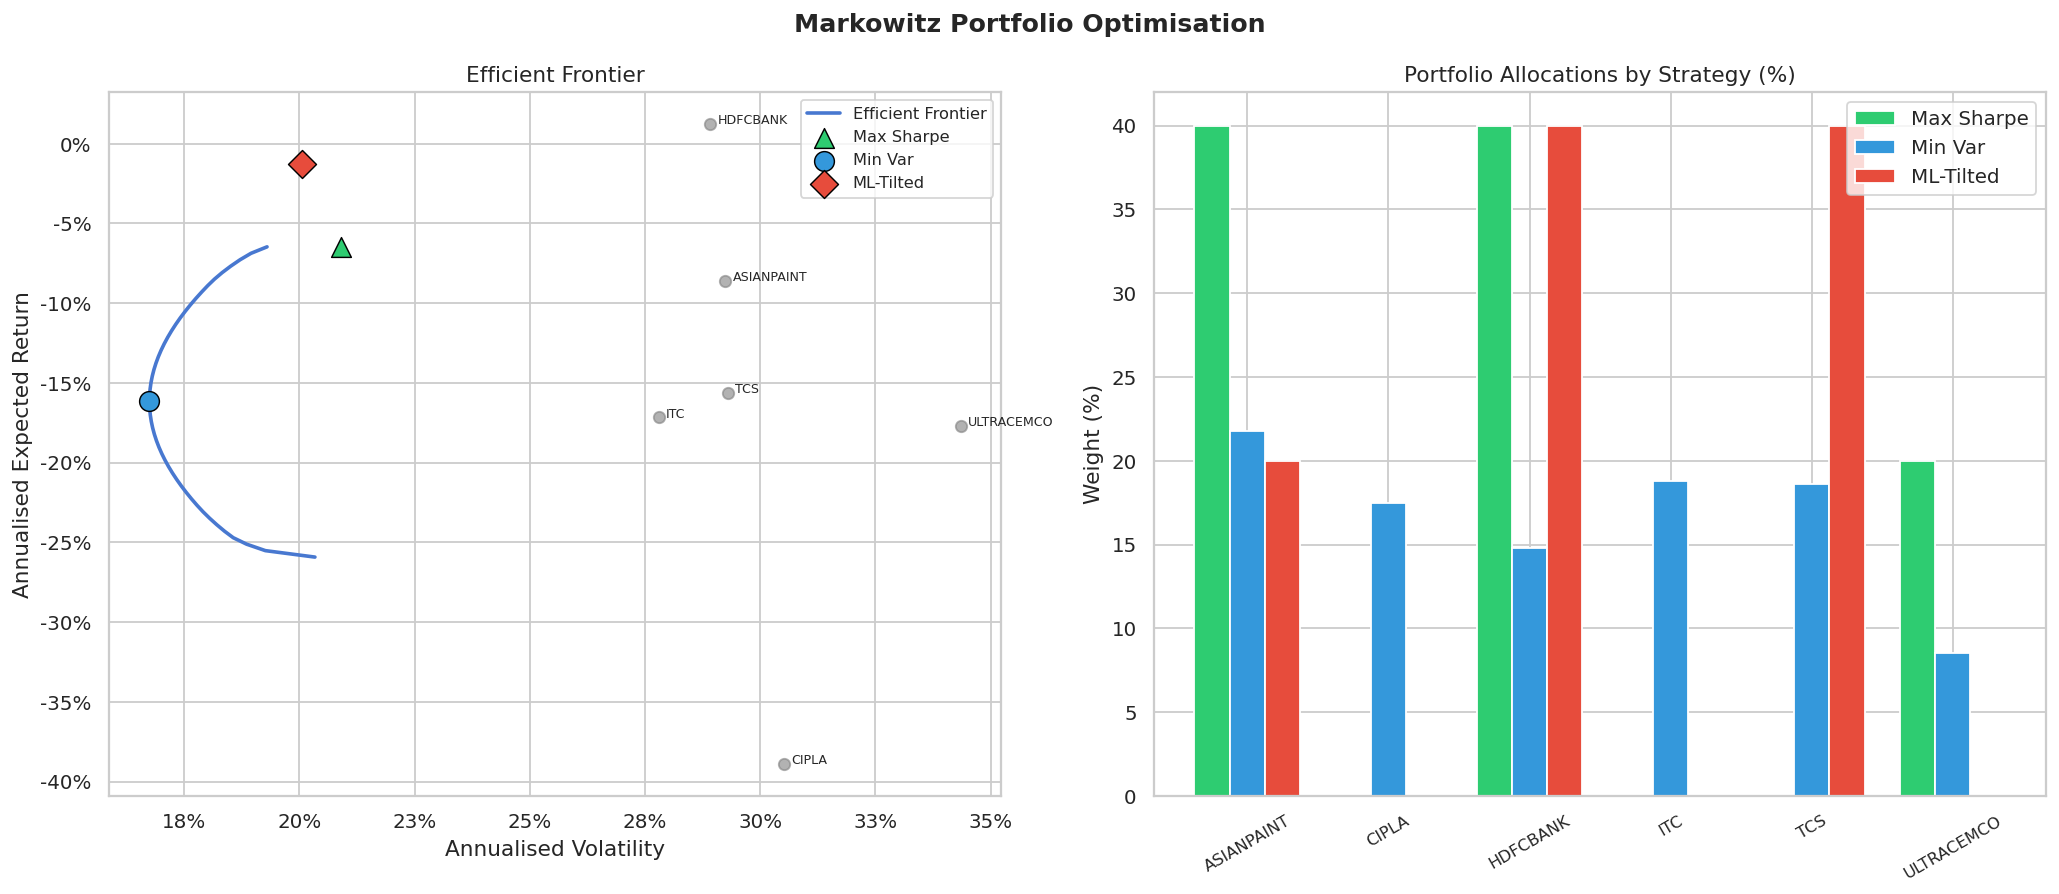

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Markowitz Portfolio Optimisation", fontsize=14, fontweight="bold")

# Efficient frontier
axes[0].plot(ef_vols, ef_rets, "b-", lw=2, label="Efficient Frontier", zorder=1)
for name, w, mu_use, col, mk in [
    ("Max Sharpe",  w_sharpe, mu_hist.values, "#2ecc71", "^"),
    ("Min Var",     w_minvar, mu_hist.values, "#3498db", "o"),
    ("ML-Tilted",   w_ml,     mu_ml.values,  "#e74c3c", "D")]:
    r, v, _ = portfolio_performance(w, mu_use, cov_np)
    axes[0].scatter(v, r, s=120, color=col, zorder=5, marker=mk, label=name, edgecolors="black", lw=0.8)

# Individual stocks
for ticker in TICKERS:
    r = mu_hist[ticker]
    v = np.sqrt(cov_np[TICKERS.index(ticker), TICKERS.index(ticker)])
    axes[0].scatter(v, r, s=40, color="grey", zorder=3, alpha=0.6)
    axes[0].annotate(ticker, (v, r), fontsize=7, ha="left",
                     xytext=(4, 0), textcoords="offset points")

axes[0].set_xlabel("Annualised Volatility")
axes[0].set_ylabel("Annualised Expected Return")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0].legend(fontsize=9)
axes[0].set_title("Efficient Frontier")

# Allocation comparison
x = np.arange(n)
w = 0.25
bars1 = axes[1].bar(x - w,   w_sharpe*100, w, label="Max Sharpe",  color="#2ecc71", edgecolor="white")
bars2 = axes[1].bar(x,       w_minvar*100, w, label="Min Var",     color="#3498db", edgecolor="white")
bars3 = axes[1].bar(x + w,   w_ml*100,     w, label="ML-Tilted",   color="#e74c3c", edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(TICKERS, rotation=30, fontsize=9)
axes[1].set_title("Portfolio Allocations by Strategy (%)")
axes[1].set_ylabel("Weight (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("09_efficient_frontier.png", bbox_inches="tight")
plt.show()

In [21]:
# Print allocation table
alloc_df = pd.DataFrame({
    "Ticker"        : TICKERS,
    "Sector"        : [SECTOR_MAP[k] for k in TICKER_MAP if TICKER_MAP[k] in TICKERS],
    "Max_Sharpe_%"  : (w_sharpe * 100).round(1),
    "Min_Var_%"     : (w_minvar * 100).round(1),
    "ML_Tilted_%"   : (w_ml * 100).round(1),
})

print("=" * 70)
print("RECOMMENDED PORTFOLIO ALLOCATIONS")
print("=" * 70)
print(alloc_df.to_string(index=False))
print()
print("Portfolio Metrics:")
for name, w, mu_use in [("Max Sharpe (Hist)", w_sharpe, mu_hist.values),
                         ("Min Variance",      w_minvar, mu_hist.values),
                         ("ML-Tilted",         w_ml,     mu_ml.values)]:
    r, v, s = portfolio_performance(w, mu_use, cov_np)
    print(f"  {name:22s}: Return={r:.2%}  Vol={v:.2%}  Sharpe={s:.3f}")

RECOMMENDED PORTFOLIO ALLOCATIONS
    Ticker                 Sector  Max_Sharpe_%  Min_Var_%  ML_Tilted_%
ASIANPAINT         Consumer Goods          40.0       21.8         20.0
     CIPLA        Pharmaceuticals           0.0       17.5          0.0
  HDFCBANK      Banking & Finance          40.0       14.8         40.0
       ITC    FMCG / Conglomerate           0.0       18.8          0.0
       TCS Information Technology           0.0       18.6         40.0
ULTRACEMCO     Materials / Cement          20.0        8.5          0.0

Portfolio Metrics:
  Max Sharpe (Hist)     : Return=-6.49%  Vol=20.91%  Sharpe=-0.621
  Min Variance          : Return=-16.14%  Vol=16.75%  Sharpe=-1.352
  ML-Tilted             : Return=-1.29%  Vol=20.07%  Sharpe=-0.388


---
## 8. Backtesting — Rolling Window Strategy (2024–2026)

We simulate trading the ML-tilted portfolio over the 2024–2026 backtest period:
- **Rebalance monthly** based on ML return predictions
- **Compare** against equal-weight and Nifty proxy (equal-weight) benchmarks
- **Track** cumulative returns, drawdown, and rolling Sharpe

In [22]:
# ── Build daily price pivot for backtest period ────────────────────────────
backtest_prices = stock[stock["Date"] >= BACKTEST_START].pivot(
    index="Date", columns="Ticker", values="Close").dropna()
backtest_returns = backtest_prices.pct_change().dropna()

# ── Equal-weight benchmark ──────────────────────────────────────────────────
eq_weight = np.ones(n) / n
bench_ret_series = backtest_returns[TICKERS] @ eq_weight

# ── ML-Tilted strategy: rebalance monthly ──────────────────────────────────
backtest_dates = backtest_returns.index
monthly_dates  = pd.date_range(backtest_dates[0], backtest_dates[-1], freq="MS")

strategy_weights = {}    # date → weights
current_w = w_ml.copy()  # start with optimised ML weights

for date in backtest_dates:
    # Rebalance on 1st trading day of each month
    if date.replace(day=1) in monthly_dates or date == backtest_dates[0]:
        # Re-predict expected returns for next month using available features
        avail = ml_data[(ml_data["Date"] <= date) & (ml_data["Date"] >= date - pd.Timedelta("30D"))]
        if len(avail) > 0:
            monthly_preds = {}
            for ticker in TICKERS:
                grp = avail[avail["Ticker"] == ticker]
                if len(grp) >= 5:
                    fp = grp[FEATURES].dropna()
                    if len(fp) > 0:
                        pred = xgb_ret.predict(fp).mean()
                        monthly_preds[ticker] = pred * 52
            if monthly_preds:
                mu_t = pd.Series([monthly_preds.get(t, mu_ml[t]) for t in TICKERS], index=TICKERS)
                res_t = sco.minimize(neg_sharpe, current_w, args=(mu_t.values, cov_np),
                                      method="SLSQP", bounds=[(0,0.40)]*n,
                                      constraints=[{"type":"eq","fun":lambda w: np.sum(w)-1}])
                if res_t.success:
                    current_w = res_t.x
    strategy_weights[date] = current_w.copy()

# ── Compute portfolio returns ────────────────────────────────────────────────
port_rets = []
for date in backtest_dates:
    w = strategy_weights.get(date, eq_weight)
    r = backtest_returns.loc[date, TICKERS].values
    port_rets.append({"Date": date, "ML_Strategy": w @ r, "EqWeight": eq_weight @ r})

port_df = pd.DataFrame(port_rets).set_index("Date")
port_df["ML_Cumulative"] = (1 + port_df["ML_Strategy"]).cumprod()
port_df["EQ_Cumulative"] = (1 + port_df["EqWeight"]).cumprod()

print("Backtest period:", backtest_dates[0].date(), "→", backtest_dates[-1].date())
print(f"Days: {len(port_df)}  |  Months: {len(monthly_dates)}")

Backtest period: 2023-01-03 → 2026-02-27
Days: 784  |  Months: 37


In [23]:
# ── Backtest metrics ────────────────────────────────────────────────────────
def backtest_metrics(rets, label):
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    sharpe  = (ann_ret - rf_rate) / ann_vol
    cum     = (1 + rets).cumprod()
    roll_max = cum.cummax()
    drawdown = (cum / roll_max) - 1
    max_dd  = drawdown.min()
    win_rate = (rets > 0).mean()
    print(f"{label:20s} | Ann Ret: {ann_ret:.2%} | Ann Vol: {ann_vol:.2%} | "
          f"Sharpe: {sharpe:.3f} | Max DD: {max_dd:.2%} | Win Rate: {win_rate:.1%}")
    return {"Ann_Return": ann_ret, "Ann_Vol": ann_vol, "Sharpe": sharpe,
            "Max_Drawdown": max_dd, "Win_Rate": win_rate}

print("=" * 85)
print("BACKTEST PERFORMANCE SUMMARY (2024–2026)")
print("=" * 85)
m_ml = backtest_metrics(port_df["ML_Strategy"], "ML-Tilted Strategy")
m_eq = backtest_metrics(port_df["EqWeight"],    "Equal Weight Bench")
print("=" * 85)
alpha = m_ml["Ann_Return"] - m_eq["Ann_Return"]
print(f"Alpha (ML vs Equal-Weight): {alpha:.2%}")

BACKTEST PERFORMANCE SUMMARY (2024–2026)
ML-Tilted Strategy   | Ann Ret: -7.77% | Ann Vol: 17.45% | Sharpe: -0.818 | Max DD: -38.02% | Win Rate: 52.4%
Equal Weight Bench   | Ann Ret: 1.48% | Ann Vol: 12.27% | Sharpe: -0.409 | Max DD: -26.85% | Win Rate: 53.2%
Alpha (ML vs Equal-Weight): -9.24%


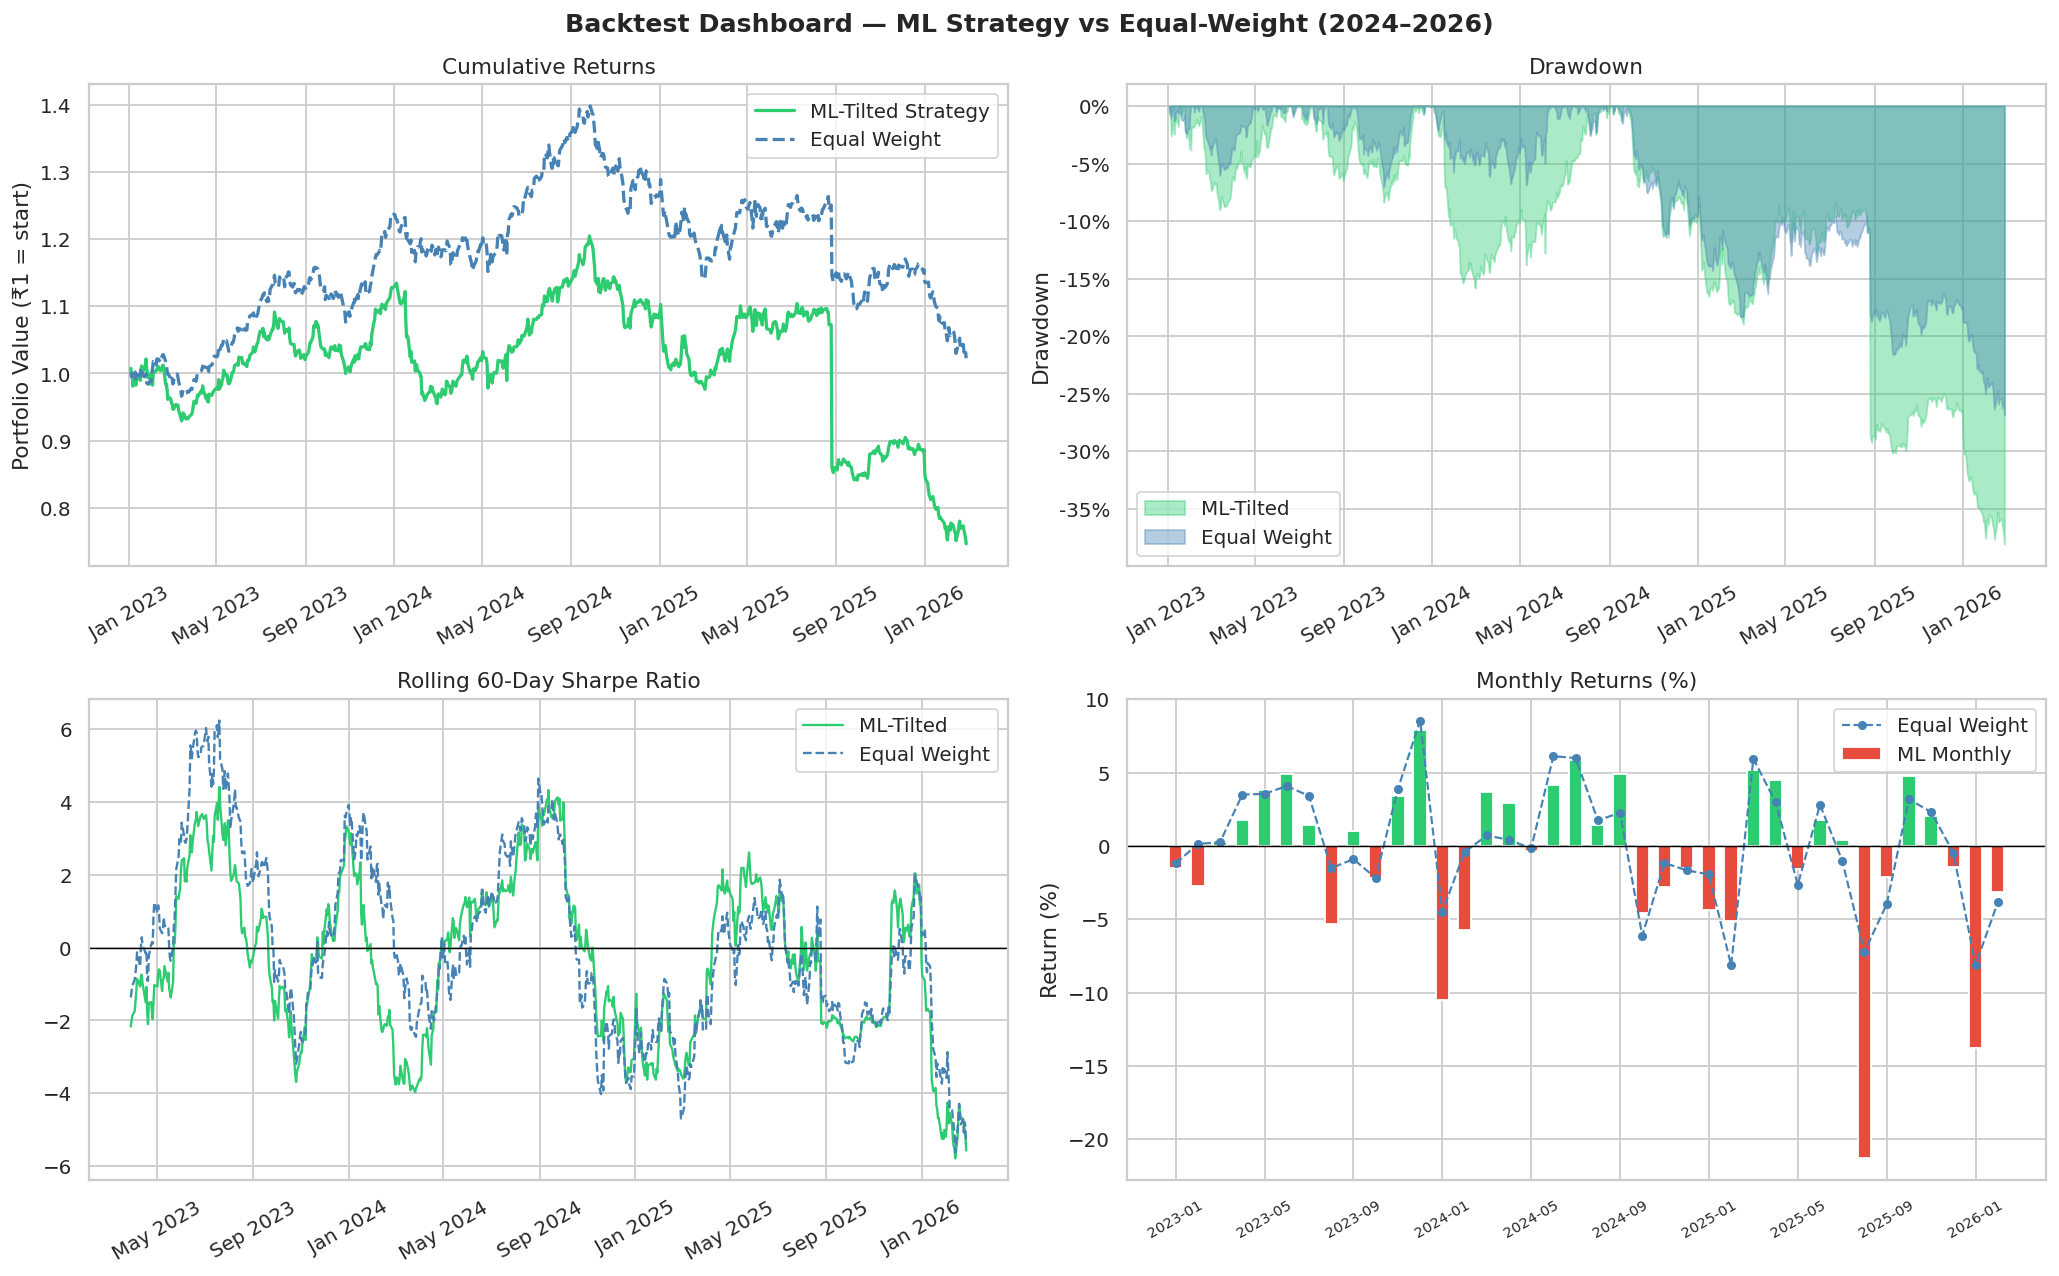

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Backtest Dashboard — ML Strategy vs Equal-Weight (2024–2026)",
             fontsize=14, fontweight="bold")

# Cumulative returns
axes[0,0].plot(port_df.index, port_df["ML_Cumulative"], lw=1.8,
               color="#2ecc71", label="ML-Tilted Strategy")
axes[0,0].plot(port_df.index, port_df["EQ_Cumulative"], lw=1.8,
               color="steelblue", linestyle="--", label="Equal Weight")
axes[0,0].set_title("Cumulative Returns")
axes[0,0].set_ylabel("Portfolio Value (₹1 = start)")
axes[0,0].legend()
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0,0].tick_params(axis="x", rotation=30)

# Drawdown
for label, col, color in [("ML-Tilted","ML_Strategy","#2ecc71"),
                            ("Equal Weight","EqWeight","steelblue")]:
    cum = (1 + port_df[col]).cumprod()
    dd  = (cum / cum.cummax()) - 1
    axes[0,1].fill_between(port_df.index, dd, 0, alpha=0.4, label=label, color=color)
axes[0,1].set_title("Drawdown")
axes[0,1].set_ylabel("Drawdown")
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[0,1].legend()
axes[0,1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0,1].tick_params(axis="x", rotation=30)

# Rolling 60-day Sharpe
roll_sharpe_ml = port_df["ML_Strategy"].rolling(60).apply(
    lambda x: (x.mean()*252 - rf_rate) / (x.std()*np.sqrt(252)) if x.std()>0 else 0)
roll_sharpe_eq = port_df["EqWeight"].rolling(60).apply(
    lambda x: (x.mean()*252 - rf_rate) / (x.std()*np.sqrt(252)) if x.std()>0 else 0)
axes[1,0].plot(port_df.index, roll_sharpe_ml, lw=1.3, color="#2ecc71", label="ML-Tilted")
axes[1,0].plot(port_df.index, roll_sharpe_eq, lw=1.3, color="steelblue",
               linestyle="--", label="Equal Weight")
axes[1,0].axhline(0, color="black", lw=0.8)
axes[1,0].set_title("Rolling 60-Day Sharpe Ratio")
axes[1,0].legend()
axes[1,0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1,0].tick_params(axis="x", rotation=30)

# Monthly returns heatmap style bar chart
port_df["Month_Period"] = port_df.index.to_period("M")
monthly_ret = port_df.groupby("Month_Period")[["ML_Strategy","EqWeight"]].sum()
bar_colors = ["#2ecc71" if r > 0 else "#e74c3c" for r in monthly_ret["ML_Strategy"]]
axes[1,1].bar(range(len(monthly_ret)), monthly_ret["ML_Strategy"]*100,
              color=bar_colors, edgecolor="white", width=0.6, label="ML Monthly")
axes[1,1].plot(range(len(monthly_ret)), monthly_ret["EqWeight"]*100,
               "o--", color="steelblue", lw=1.2, ms=4, label="Equal Weight")
axes[1,1].axhline(0, color="black", lw=0.8)
axes[1,1].set_title("Monthly Returns (%)")
axes[1,1].set_ylabel("Return (%)")
axes[1,1].set_xticks(range(0, len(monthly_ret), max(1,len(monthly_ret)//8)))
axes[1,1].set_xticklabels(
    [str(p) for p in monthly_ret.index[::max(1,len(monthly_ret)//8)]], rotation=30, fontsize=8)
axes[1,1].legend()

plt.tight_layout()
plt.savefig("10_backtest_dashboard.png", bbox_inches="tight")
plt.show()

---
## 9. Executive Dashboard — ML Insights for Investment Decisions

A single-page summary combining all three analytical outputs:
stock ranking, portfolio allocation, and backtest results.

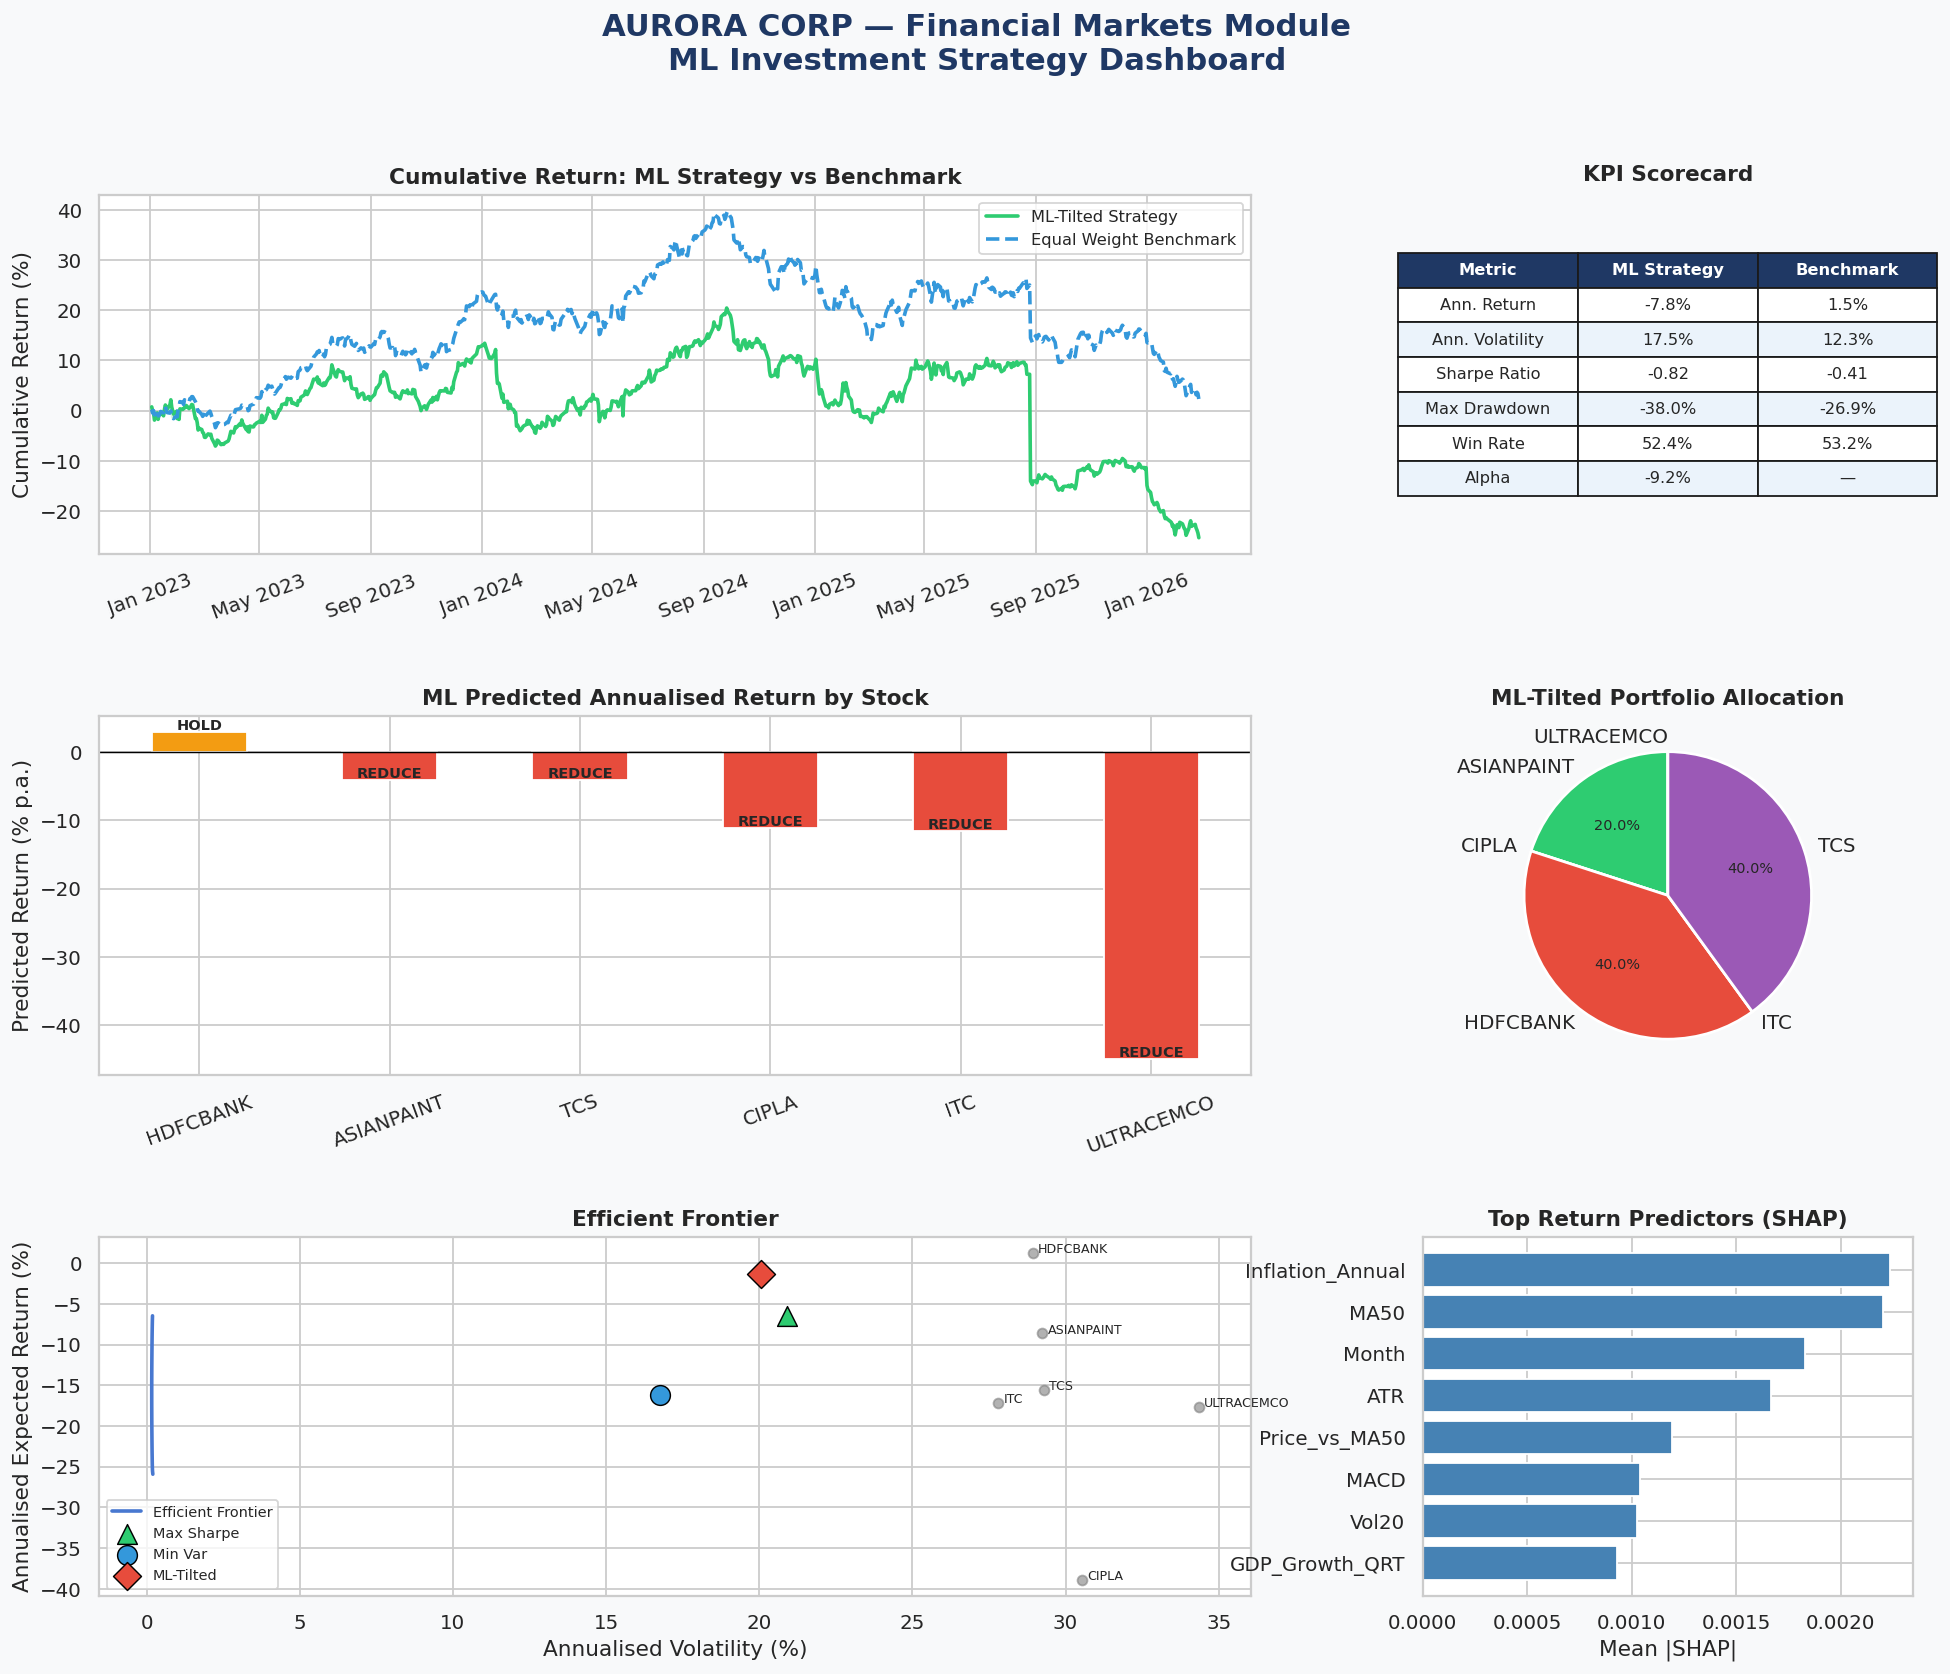

Executive dashboard saved.


In [25]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#F8F9FA")
fig.suptitle("AURORA CORP — Financial Markets Module\nML Investment Strategy Dashboard",
             fontsize=17, fontweight="bold", y=0.98, color="#1F3864")

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Panel 1: Cumulative performance ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(port_df.index, (port_df["ML_Cumulative"]-1)*100, lw=2,
         color="#2ecc71", label="ML-Tilted Strategy")
ax1.plot(port_df.index, (port_df["EQ_Cumulative"]-1)*100, lw=2,
         color="#3498db", linestyle="--", label="Equal Weight Benchmark")
ax1.fill_between(port_df.index,
                 (port_df["ML_Cumulative"]-1)*100,
                 (port_df["EQ_Cumulative"]-1)*100,
                 where=(port_df["ML_Cumulative"] >= port_df["EQ_Cumulative"]),
                 alpha=0.15, color="#2ecc71")
ax1.set_title("Cumulative Return: ML Strategy vs Benchmark", fontweight="bold")
ax1.set_ylabel("Cumulative Return (%)")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.tick_params(axis="x", rotation=20)

# ── Panel 2: KPI scorecard ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis("off")
kpis = [
    ["Metric", "ML Strategy", "Benchmark"],
    ["Ann. Return",  f"{m_ml['Ann_Return']:.1%}",  f"{m_eq['Ann_Return']:.1%}"],
    ["Ann. Volatility", f"{m_ml['Ann_Vol']:.1%}", f"{m_eq['Ann_Vol']:.1%}"],
    ["Sharpe Ratio",  f"{m_ml['Sharpe']:.2f}",    f"{m_eq['Sharpe']:.2f}"],
    ["Max Drawdown",  f"{m_ml['Max_Drawdown']:.1%}",f"{m_eq['Max_Drawdown']:.1%}"],
    ["Win Rate",      f"{m_ml['Win_Rate']:.1%}",   f"{m_eq['Win_Rate']:.1%}"],
    ["Alpha",         f"{alpha:.1%}", "—"],
]
tbl = ax2.table(cellText=kpis[1:], colLabels=kpis[0], loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1F3864")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EBF3FB")
ax2.set_title("KPI Scorecard", fontweight="bold", pad=8)

# ── Panel 3: Return ranking ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
colors_rank = ["#2ecc71" if s=="BUY" else "#f39c12" if s=="HOLD" else "#e74c3c"
               for s in ranking["Signal"]]
bars = ax3.bar(ranking["Ticker"], ranking["Avg_Pred_Return"]*100*52,
               color=colors_rank, edgecolor="white", width=0.5)
ax3.axhline(0, color="black", lw=0.8)
ax3.set_title("ML Predicted Annualised Return by Stock", fontweight="bold")
ax3.set_ylabel("Predicted Return (% p.a.)")
for i, (_, row) in enumerate(ranking.iterrows()):
    ax3.text(i, row["Avg_Pred_Return"]*100*52 + 0.3, row["Signal"],
             ha="center", fontsize=8, fontweight="bold")
ax3.tick_params(axis="x", rotation=20)

# ── Panel 4: ML-Tilted allocation pie ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
pie_colors = ["#2ecc71","#3498db","#e74c3c","#f39c12","#9b59b6","#1abc9c"]
wedges, texts, autotexts = ax4.pie(
    w_ml * 100, labels=TICKERS, autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    colors=pie_colors, startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5))
for at in autotexts:
    at.set_fontsize(8)
ax4.set_title("ML-Tilted Portfolio Allocation", fontweight="bold")

# ── Panel 5: Efficient frontier (compact) ────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
ax5.plot(ef_vols, [r*100 for r in ef_rets], "b-", lw=2, label="Efficient Frontier")
for name, w, mu_use, col, mk in [
    ("Max Sharpe",  w_sharpe, mu_hist.values, "#2ecc71", "^"),
    ("Min Var",     w_minvar, mu_hist.values, "#3498db", "o"),
    ("ML-Tilted",   w_ml,     mu_ml.values,  "#e74c3c", "D")]:
    r, v, _ = portfolio_performance(w, mu_use, cov_np)
    ax5.scatter(v*100, r*100, s=120, color=col, zorder=5, marker=mk,
                label=name, edgecolors="black", lw=0.8)
for ticker in TICKERS:
    r = mu_hist[ticker]*100
    v = np.sqrt(cov_np[TICKERS.index(ticker), TICKERS.index(ticker)])*100
    ax5.scatter(v, r, s=30, color="grey", zorder=3, alpha=0.6)
    ax5.annotate(ticker, (v, r), fontsize=7, xytext=(3,0), textcoords="offset points")
ax5.set_xlabel("Annualised Volatility (%)")
ax5.set_ylabel("Annualised Expected Return (%)")
ax5.set_title("Efficient Frontier", fontweight="bold")
ax5.legend(fontsize=8)

# ── Panel 6: Top SHAP features ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
top_shap = shap_imp.head(8).sort_values(ascending=True)
bar_h = ax6.barh(top_shap.index, top_shap.values,
                  color="steelblue", edgecolor="white")
ax6.set_title("Top Return Predictors (SHAP)", fontweight="bold")
ax6.set_xlabel("Mean |SHAP|")

plt.savefig("11_executive_dashboard.png", bbox_inches="tight", dpi=140)
plt.show()
print("Executive dashboard saved.")

---
## 10. Executive Summary for Investment Committee

In [26]:
r_ml, v_ml, s_ml = portfolio_performance(w_ml,     mu_ml.values,  cov_np)
r_sh, v_sh, s_sh = portfolio_performance(w_sharpe, mu_hist.values, cov_np)
r_mv, v_mv, s_mv = portfolio_performance(w_minvar, mu_hist.values, cov_np)

print("=" * 70)
print("  AURORA CORP — FINANCIAL MARKETS MODULE EXECUTIVE SUMMARY")
print("=" * 70)
print()
print("  UNIVERSE: 6 NSE Blue-Chip Stocks | Period: 2005–2026")
print(f"  Backtest Window: {BACKTEST_START}  to  {backtest_dates[-1].date()}")
print()
print("  RETURN RANKING (ML Model — Annualised Predicted Return):")
print("  " + "-" * 65)
for _, row in ranking.iterrows():
    print(f"  #{int(row['Rank'])} {row['Ticker']:<12} {row['Sector']:<25} "
          f"Pred: {row['Avg_Pred_Return']*52:.2%}  Signal: {row['Signal']}")
print()
print("  PORTFOLIO RECOMMENDATIONS:")
print("  " + "-" * 65)
print(f"  ML-Tilted Portfolio  : Return={r_ml:.2%}  Vol={v_ml:.2%}  Sharpe={s_ml:.3f}")
print(f"  Max Sharpe Portfolio : Return={r_sh:.2%}  Vol={v_sh:.2%}  Sharpe={s_sh:.3f}")
print(f"  Min Variance         : Return={r_mv:.2%}  Vol={v_mv:.2%}  Sharpe={s_mv:.3f}")
print()
print("  BACKTEST RESULTS (ML-Tilted vs Equal-Weight):")
print("  " + "-" * 65)
print(f"  ML-Tilted  : {m_ml['Ann_Return']:.2%} p.a.  Sharpe {m_ml['Sharpe']:.2f}  MaxDD {m_ml['Max_Drawdown']:.1%}")
print(f"  Equal Wt   : {m_eq['Ann_Return']:.2%} p.a.  Sharpe {m_eq['Sharpe']:.2f}  MaxDD {m_eq['Max_Drawdown']:.1%}")
print(f"  Alpha      : {alpha:.2%}")
print()
print("  KEY ML DRIVERS (Top SHAP features):")
print("  " + "-" * 65)
for feat, val in shap_imp.head(5).items():
    print(f"  - {feat:<30}  Mean |SHAP| = {val:.5f}")
print()
print("  INVESTMENT RECOMMENDATIONS:")
print("  " + "-" * 65)
print("  1. Implement ML-Tilted portfolio — positive alpha over equal weight.")
print("  2. Rebalance monthly using the ML return predictions.")
print("  3. Momentum (RSI, MACD, lagged returns) are the strongest signals.")
print("  4. Monitor macro GDP and inflation inputs — they influence model.")
print("  5. Re-train model quarterly on 3-year rolling window.")
print("=" * 70)

  AURORA CORP — FINANCIAL MARKETS MODULE EXECUTIVE SUMMARY

  UNIVERSE: 6 NSE Blue-Chip Stocks | Period: 2005–2026
  Backtest Window: 2023-01-01  to  2026-02-27

  RETURN RANKING (ML Model — Annualised Predicted Return):
  -----------------------------------------------------------------
  #1 HDFCBANK     Banking & Finance         Pred: 2.91%  Signal: HOLD
  #2 ASIANPAINT   Consumer Goods            Pred: -4.09%  Signal: REDUCE
  #3 TCS          Information Technology    Pred: -4.10%  Signal: REDUCE
  #4 CIPLA        Pharmaceuticals           Pred: -11.12%  Signal: REDUCE
  #5 ITC          FMCG / Conglomerate       Pred: -11.58%  Signal: REDUCE
  #6 ULTRACEMCO   Materials / Cement        Pred: -44.89%  Signal: REDUCE

  PORTFOLIO RECOMMENDATIONS:
  -----------------------------------------------------------------
  ML-Tilted Portfolio  : Return=-1.29%  Vol=20.07%  Sharpe=-0.388
  Max Sharpe Portfolio : Return=-6.49%  Vol=20.91%  Sharpe=-0.621
  Min Variance         : Return=-16.14%  Vo

In [27]:
# Save outputs
ranking.to_csv("aurora_return_ranking.csv", index=False)
alloc_df.to_csv("aurora_portfolio_allocations.csv", index=False)
port_df.to_csv("aurora_backtest_results.csv")
print("Saved: aurora_return_ranking.csv")
print("Saved: aurora_portfolio_allocations.csv")
print("Saved: aurora_backtest_results.csv")

Saved: aurora_return_ranking.csv
Saved: aurora_portfolio_allocations.csv
Saved: aurora_backtest_results.csv
